In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [6]:
cols = ["flength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("magic04.data", names=cols)
df.head()

,flength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [7]:
df['class'] = (df['class'] == 'g').astype(int)

In [8]:
df.head()

,flength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


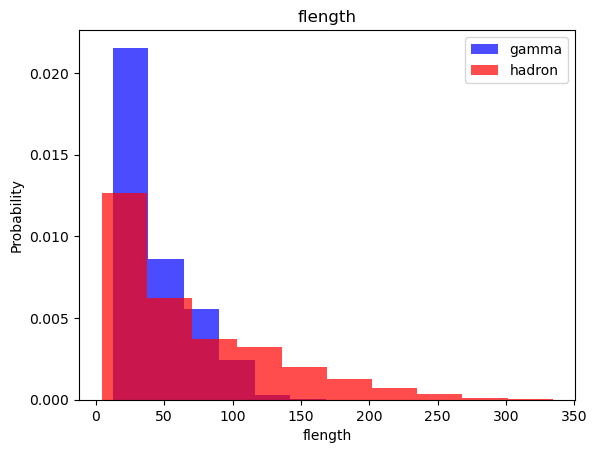

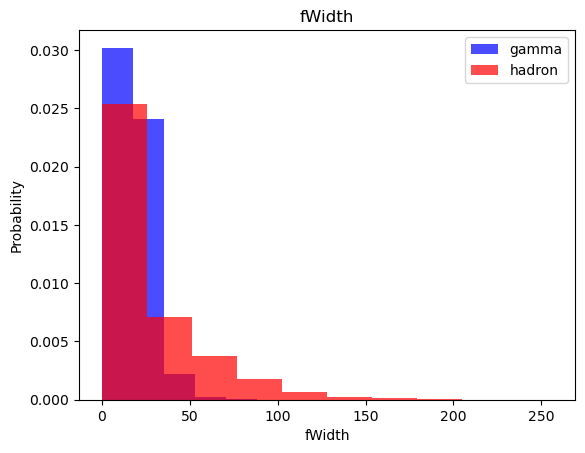

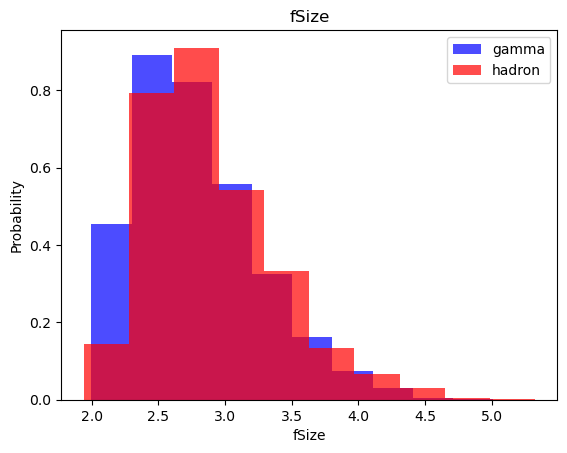

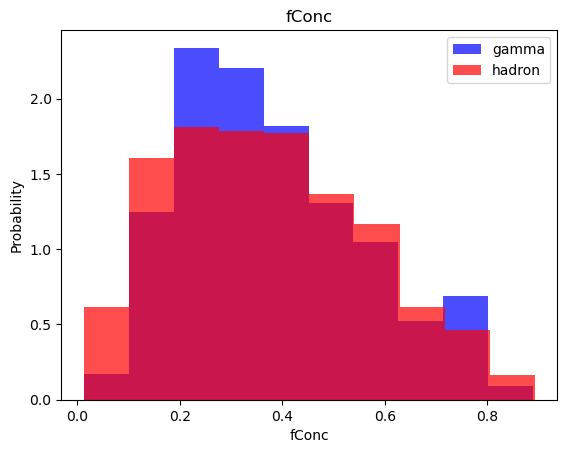

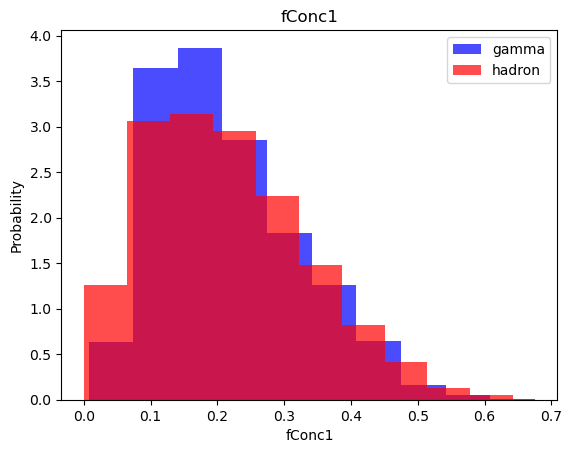

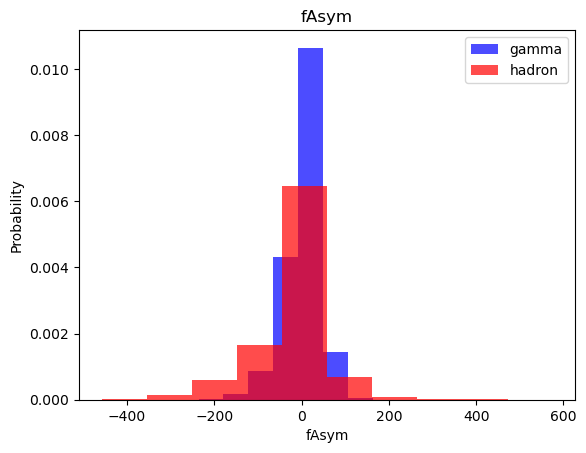

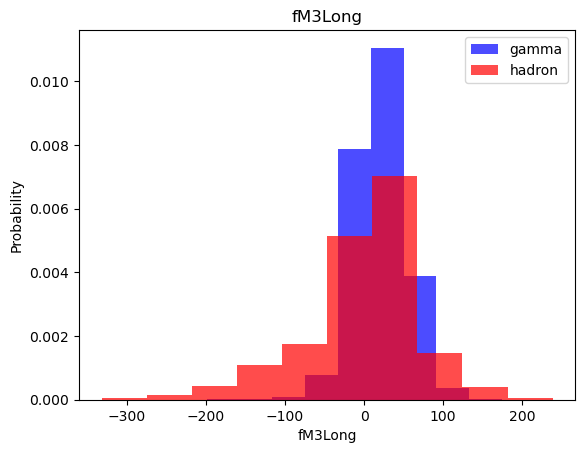

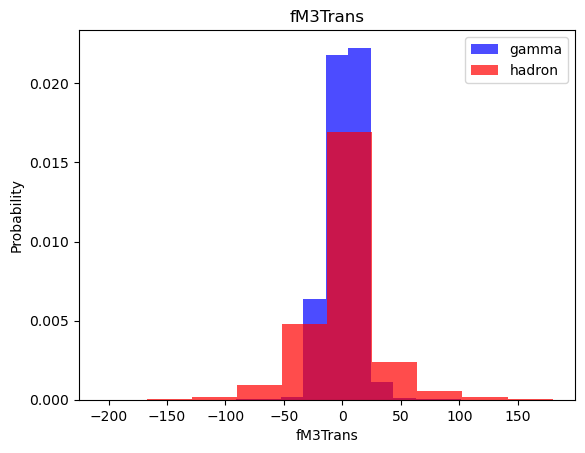

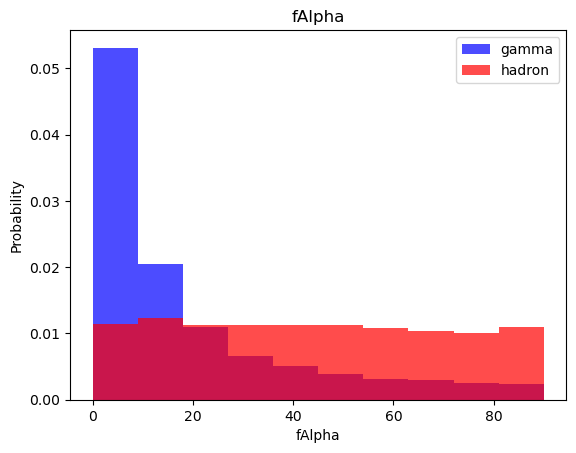

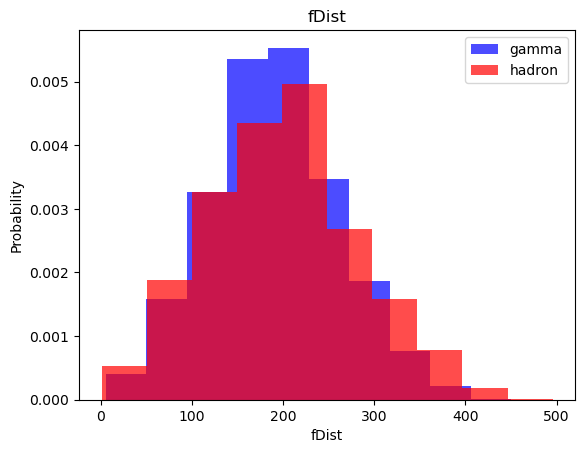

In [9]:
for label in cols[:-1]:
    plt.hist(df[df['class'] == 1][label], color="blue", label="gamma", alpha=0.7, density=True)
    plt.hist(df[df['class'] == 0][label], color="red", label="hadron", alpha=0.7, density=True)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)
    plt.legend()
    plt.show()

# Train valid test datasets


In [10]:
# train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

In [11]:
train, valid, test = np.split(
    df.sample(frac=1),
    [int(0.6 * len(df)), int(0.8 * len(df))]
)

train = pd.DataFrame(train, columns=df.columns)
valid = pd.DataFrame(valid, columns=df.columns)
test = pd.DataFrame(test, columns=df.columns)

In [12]:
train

,flength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,38.9505,10.6421,2.5551,0.4624,0.2382,38.9554,-7.1855,11.4823,61.4540,159.8400,0.0
1,100.1570,9.2877,2.3345,0.6481,0.4421,-112.0530,59.4849,8.4801,36.4320,289.7850,0.0
2,70.1638,27.6647,3.5497,0.1512,0.0760,31.4363,58.6011,-17.7328,8.3983,238.2590,1.0
3,57.1656,19.9402,2.9978,0.1970,0.1000,11.2262,44.4537,14.2419,12.2670,247.1140,1.0
4,52.3850,39.3619,3.0348,0.1716,0.0835,-14.1773,-52.7253,-26.9833,72.0321,171.9525,0.0
...,...,...,...,...,...,...,...,...,...,...,...
11407,23.0242,13.2275,2.2188,0.4471,0.2326,-25.6063,-10.4290,5.5499,33.4008,210.8190,1.0
11408,31.3831,8.8940,2.6484,0.5146,0.3404,-5.9901,22.6490,5.7042,20.2080,55.8071,0.0
11409,26.0211,9.5427,2.4005,0.5050,0.2883,-10.0603,11.2665,-4.0374,10.2299,144.9260,1.0
11410,17.6798,10.9569,2.2148,0.5366,0.2957,-0.5043,4.9753,-4.8227,82.0150,180.9830,1.0


In [13]:
def scale_dataset(dataframe, oversample=False):
    X = dataframe[dataframe.columns[:-1]].values
    y = dataframe[dataframe.columns[-1]].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1, 1))))

    return data, X, y

In [14]:
train, X_train, y_train = scale_dataset(train, oversample=True)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)

# kNN

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [16]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [17]:
y_pred = knn_model.predict(X_test)

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.74      0.73      0.73      1362
         1.0       0.85      0.85      0.85      2442

    accuracy                           0.81      3804
   macro avg       0.79      0.79      0.79      3804
weighted avg       0.81      0.81      0.81      3804



# Naive Bayes

In [19]:
from sklearn.naive_bayes import GaussianNB

In [20]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [21]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.69      0.41      0.51      1362
         1.0       0.73      0.90      0.81      2442

    accuracy                           0.72      3804
   macro avg       0.71      0.65      0.66      3804
weighted avg       0.72      0.72      0.70      3804



# logistic Regression


In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [24]:
y_pred = lg_model.predict(X_test)


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.69      0.72      0.70      1362
         1.0       0.84      0.82      0.83      2442

    accuracy                           0.78      3804
   macro avg       0.76      0.77      0.77      3804
weighted avg       0.79      0.78      0.78      3804



In [26]:
from sklearn.svm import SVC

In [27]:
svc_model = SVC()
svc_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
y_pred = svc_model.predict(X_test)

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.80      0.80      0.80      1362
         1.0       0.89      0.89      0.89      2442

    accuracy                           0.86      3804
   macro avg       0.85      0.84      0.85      3804
weighted avg       0.86      0.86      0.86      3804



# Tensorflow


In [30]:
import tensorflow as tf

In [31]:
def train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,)),
        tf.keras.layers.Dropout(dropout_prob),  
        tf.keras.layers.Dense(num_nodes, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),  
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    nn_model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy", metrics=['accuracy'])
    history = nn_model.fit(
        X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose = 0
    )

    return nn_model, history

In [34]:
def plot_history(history):
    fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(10, 8))
    axis1.plot(history.history['loss'], label='loss')
    axis1.plot(history.history['val_loss'], label='val_loss')
    axis1.set_xlabel('Epoch')
    axis1.set_ylabel('Binary crossentropy')
    axis1.grid(True)

    axis2.plot(history.history['accuracy'], label='accuracy')
    axis2.plot(history.history['val_accuracy'], label='val_accuracy')
    axis2.set_xlabel('Epoch')
    axis2.set_ylabel('accuracy')
    axis2.grid(True)
    plt.show()

16 nodes, dropout 0, lr 0.1, batch_size 32, epochs 100


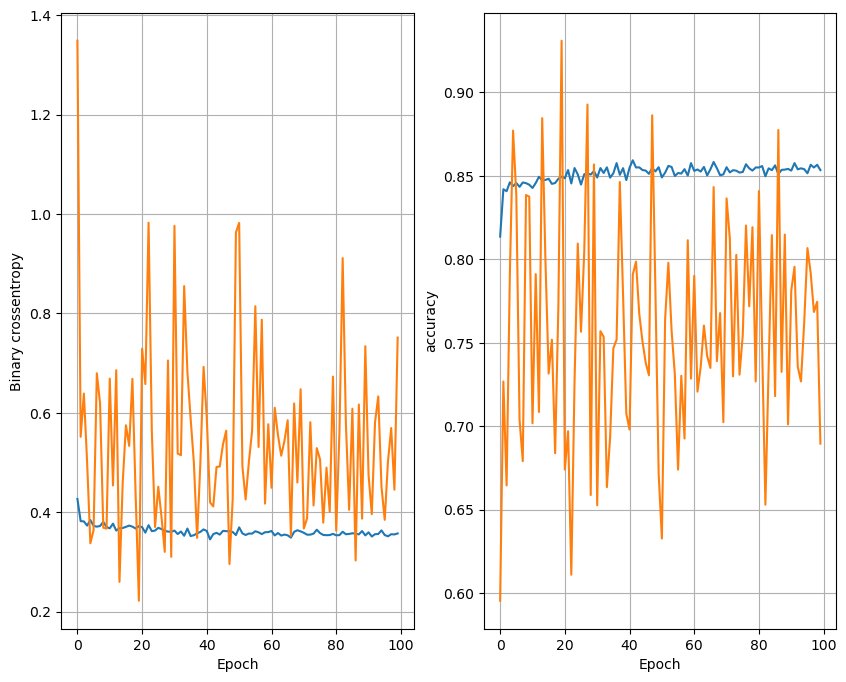

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8620 - loss: 0.3626
16 nodes, dropout 0, lr 0.1, batch_size 64, epochs 100


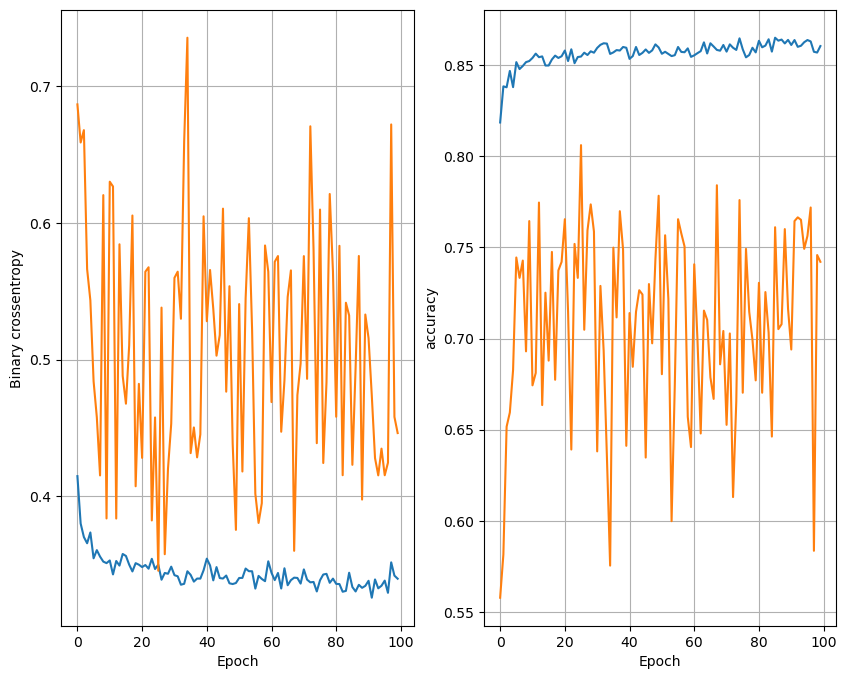

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8633 - loss: 0.3522
16 nodes, dropout 0, lr 0.1, batch_size 128, epochs 100


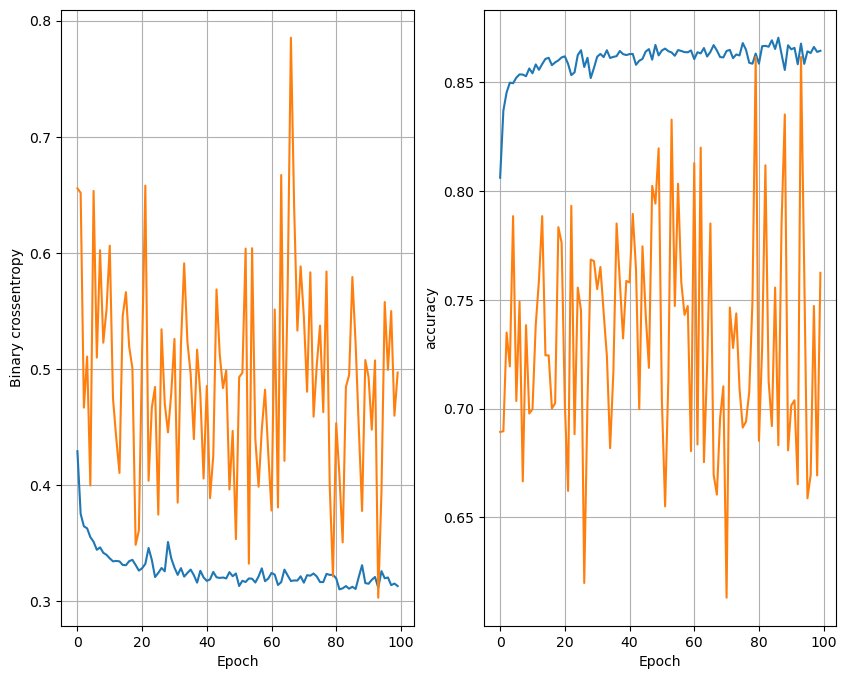

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8630 - loss: 0.3231
16 nodes, dropout 0, lr 0.005, batch_size 32, epochs 100


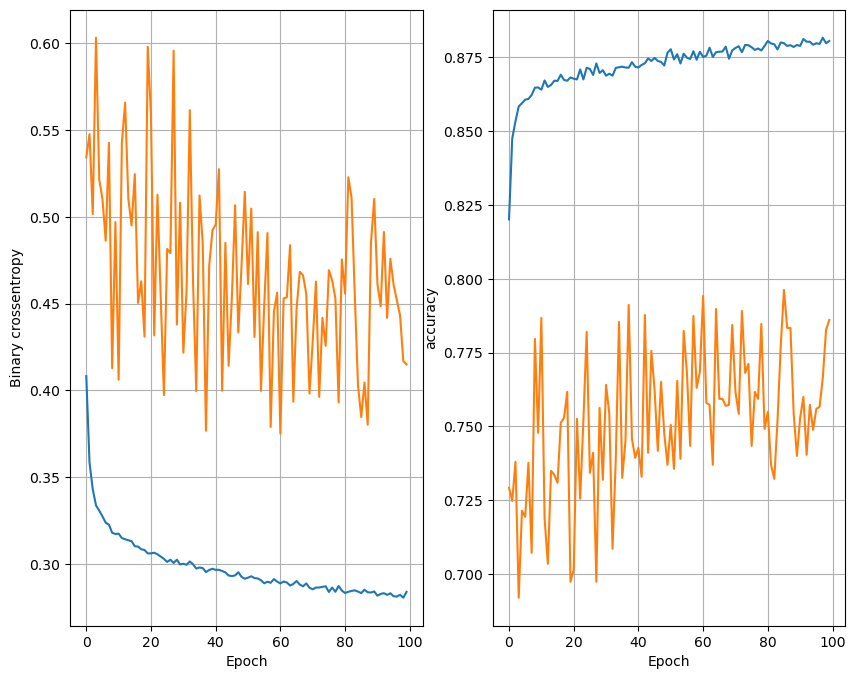

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8654 - loss: 0.3261
16 nodes, dropout 0, lr 0.005, batch_size 64, epochs 100


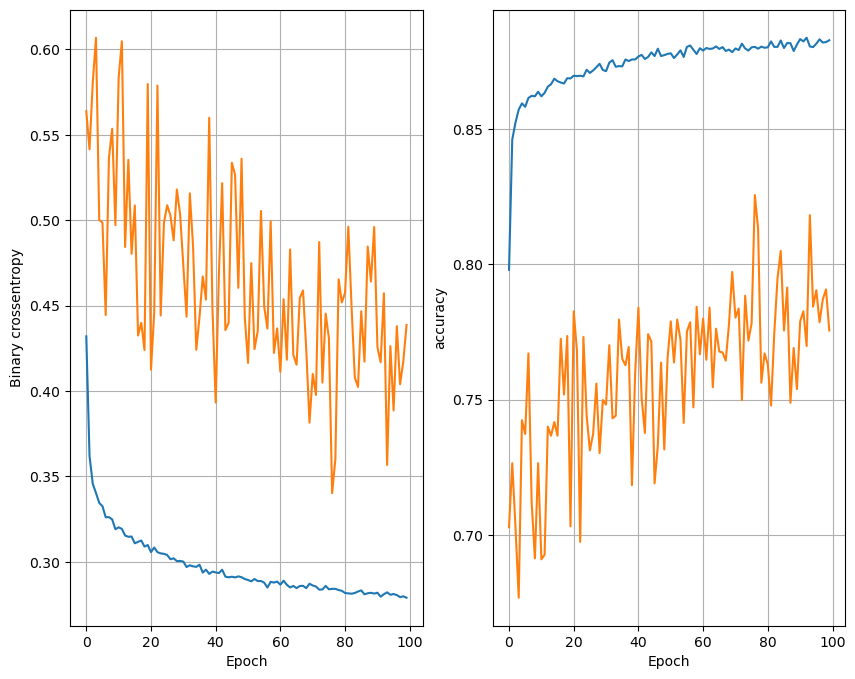

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8667 - loss: 0.3144
16 nodes, dropout 0, lr 0.005, batch_size 128, epochs 100


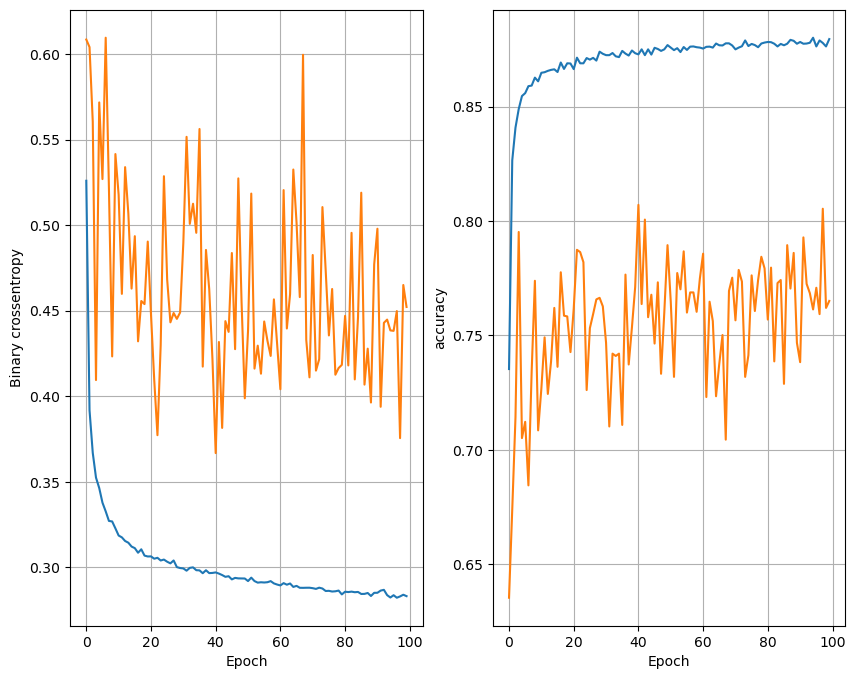

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8720 - loss: 0.3222
16 nodes, dropout 0, lr 0.001, batch_size 32, epochs 100


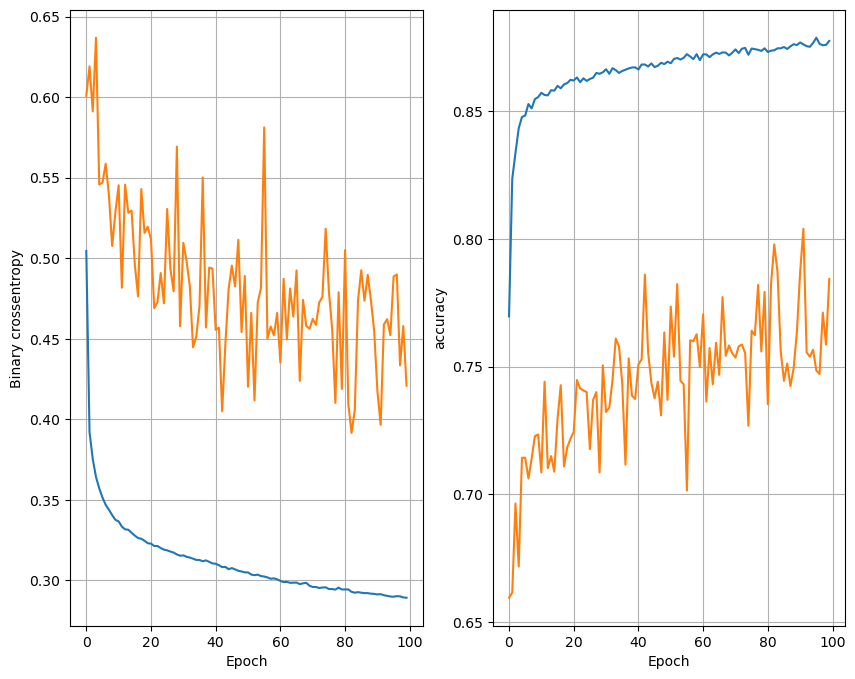

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8683 - loss: 0.3127
16 nodes, dropout 0, lr 0.001, batch_size 64, epochs 100


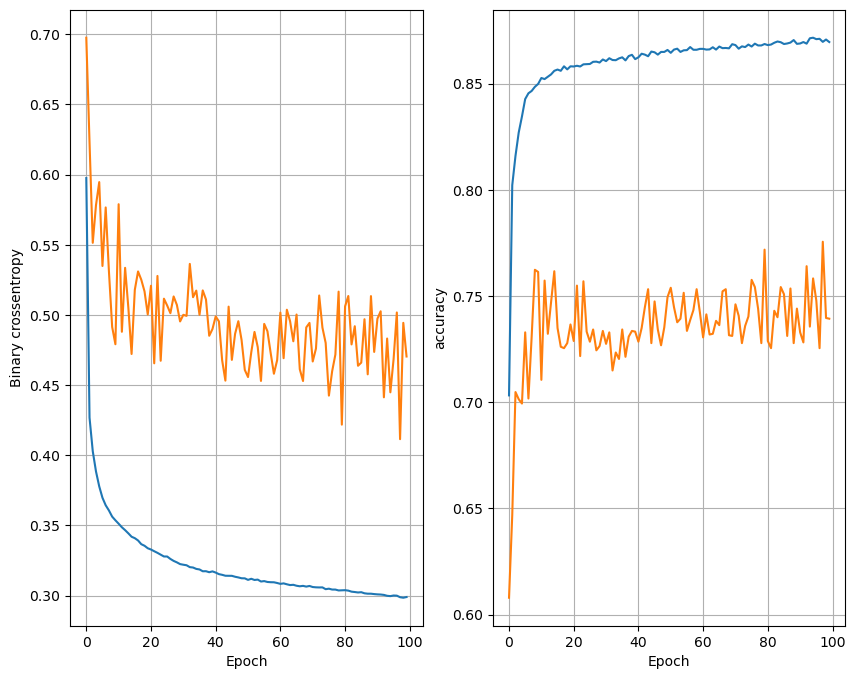

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8720 - loss: 0.3092
16 nodes, dropout 0, lr 0.001, batch_size 128, epochs 100


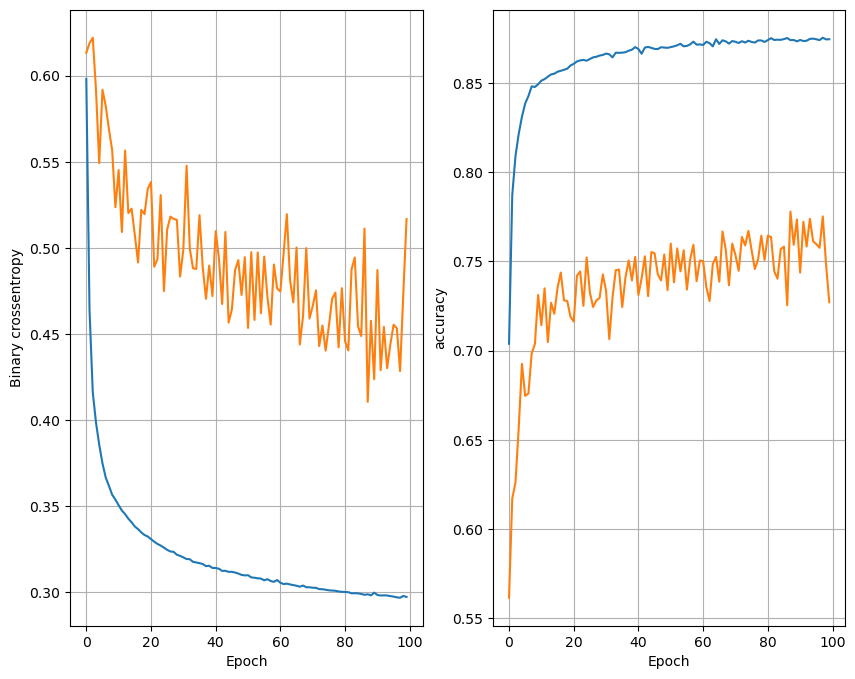

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8741 - loss: 0.3140
16 nodes, dropout 0.2, lr 0.1, batch_size 32, epochs 100


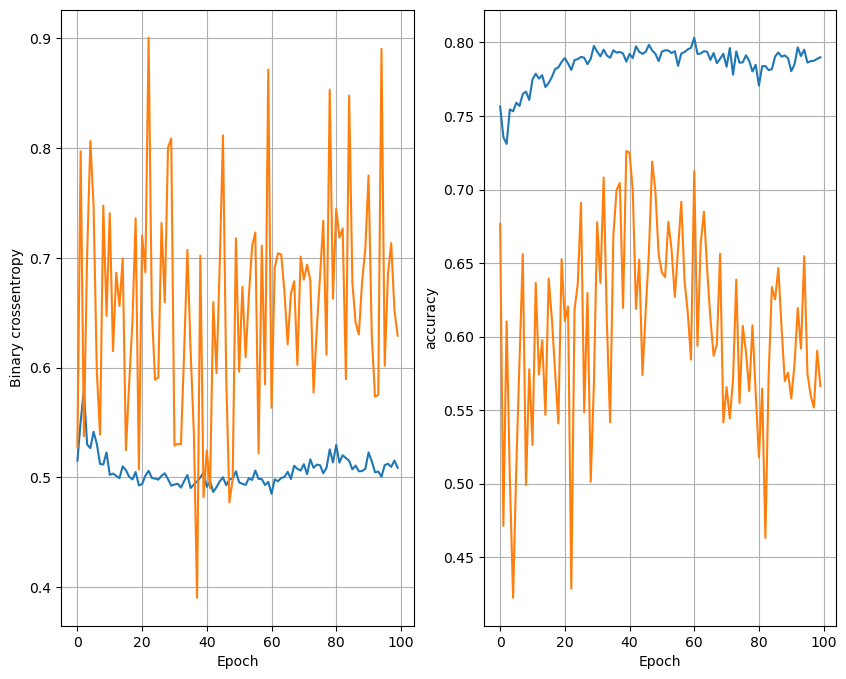

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8389 - loss: 0.4566
16 nodes, dropout 0.2, lr 0.1, batch_size 64, epochs 100


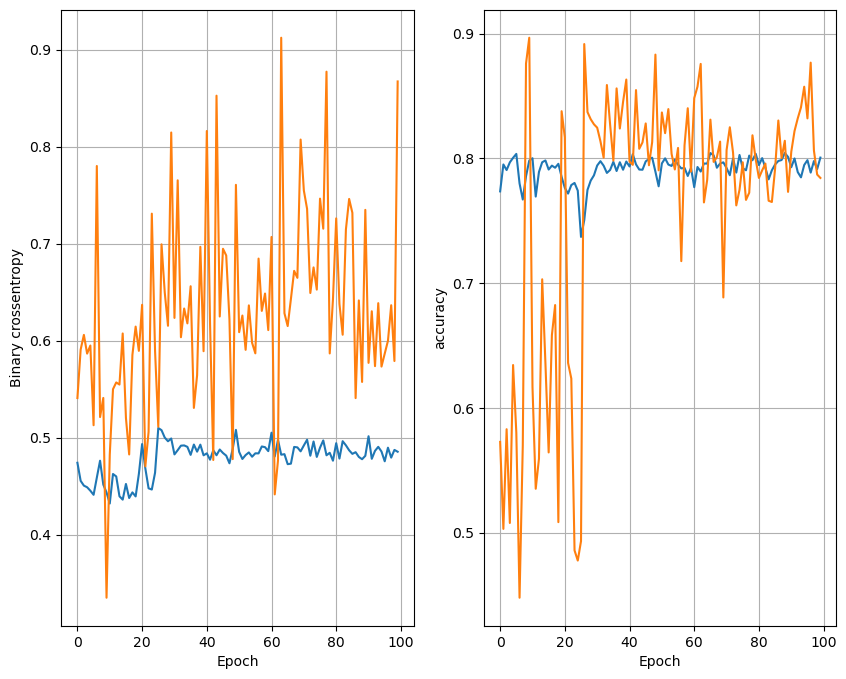

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8055 - loss: 0.4602
16 nodes, dropout 0.2, lr 0.1, batch_size 128, epochs 100


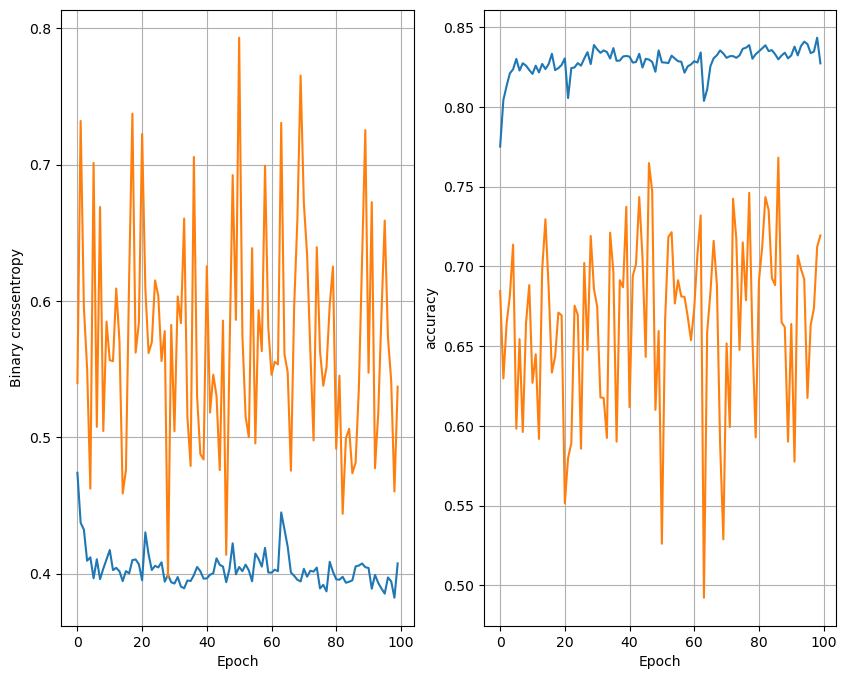

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8657 - loss: 0.3508
16 nodes, dropout 0.2, lr 0.005, batch_size 32, epochs 100


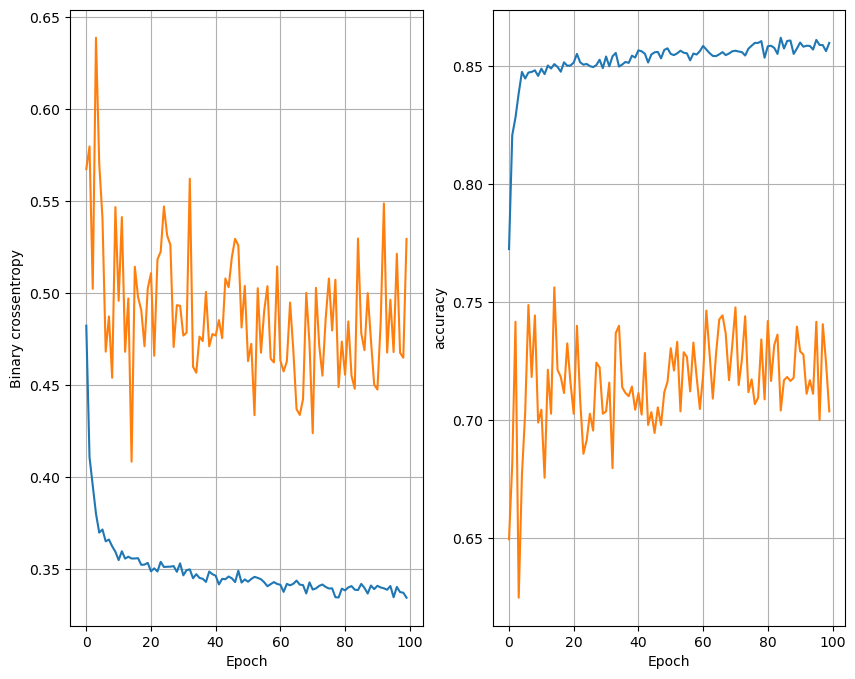

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8738 - loss: 0.3182
16 nodes, dropout 0.2, lr 0.005, batch_size 64, epochs 100


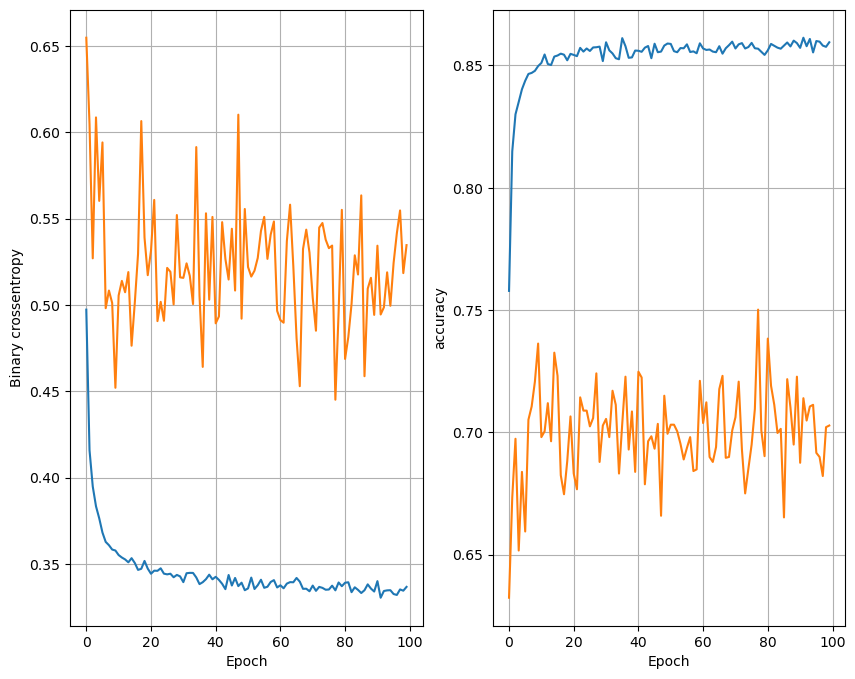

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8720 - loss: 0.3104
16 nodes, dropout 0.2, lr 0.005, batch_size 128, epochs 100


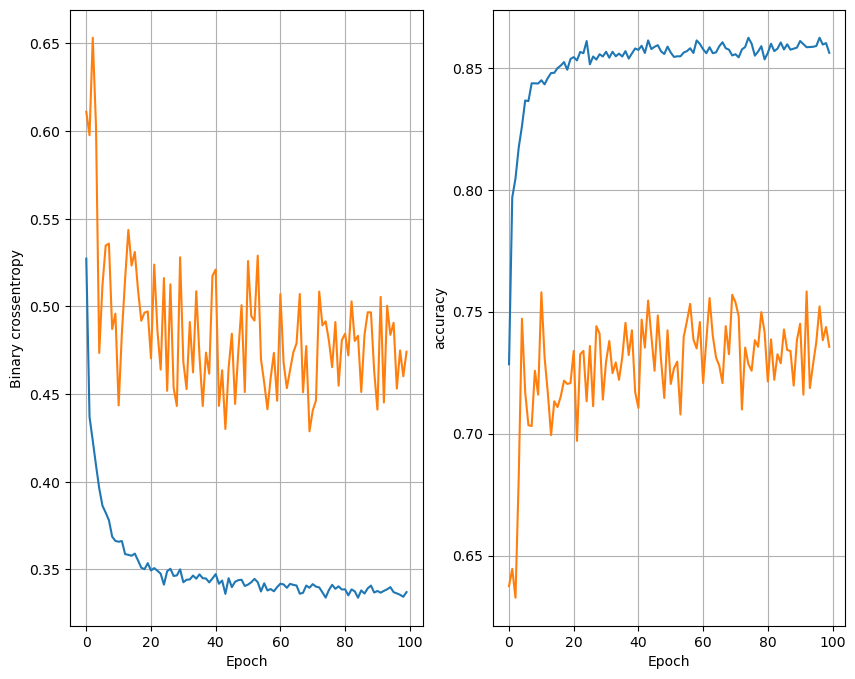

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8672 - loss: 0.3199
16 nodes, dropout 0.2, lr 0.001, batch_size 32, epochs 100


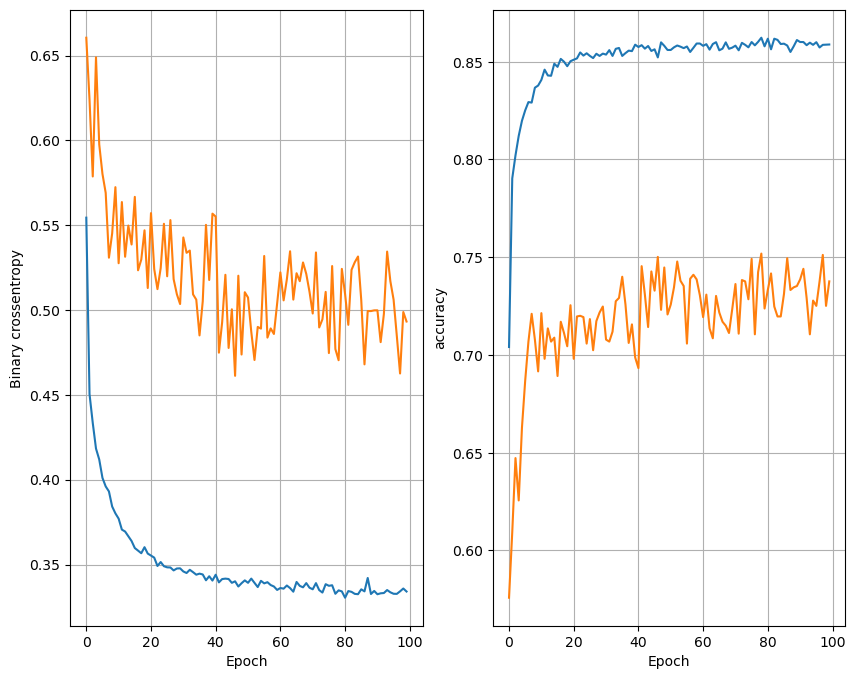

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8701 - loss: 0.3191
16 nodes, dropout 0.2, lr 0.001, batch_size 64, epochs 100


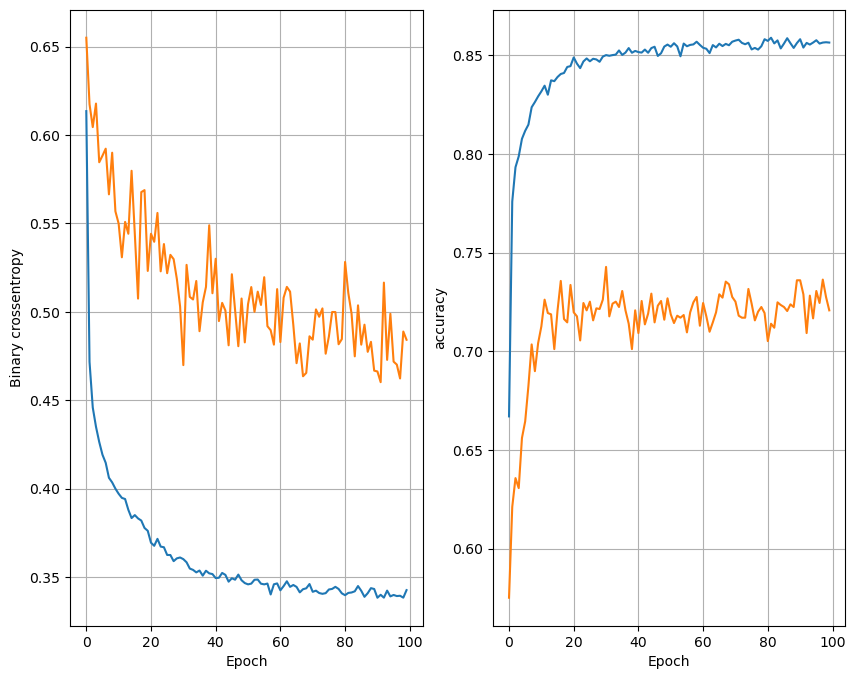

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8678 - loss: 0.3180
16 nodes, dropout 0.2, lr 0.001, batch_size 128, epochs 100


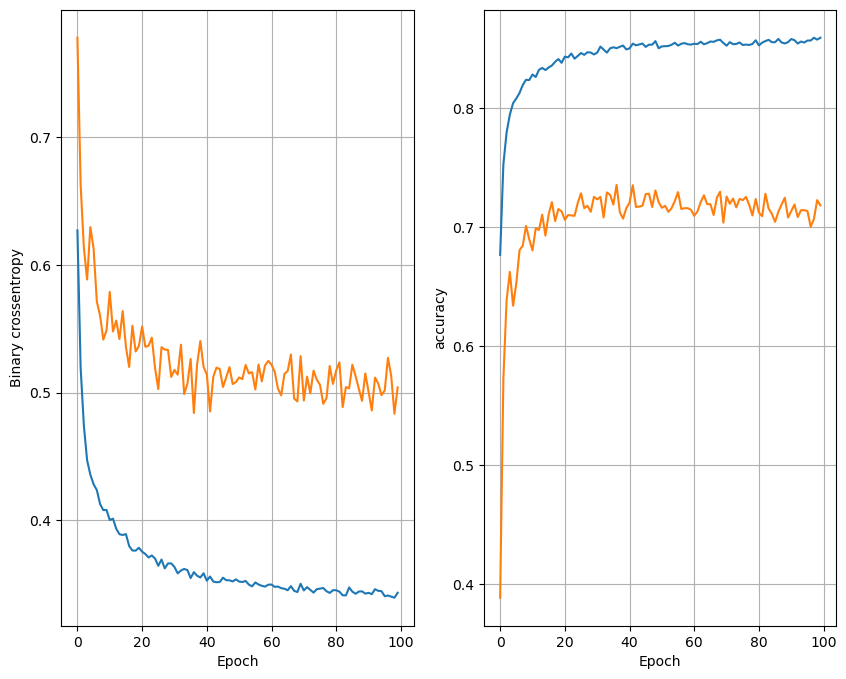

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8701 - loss: 0.3170
32 nodes, dropout 0, lr 0.1, batch_size 32, epochs 100


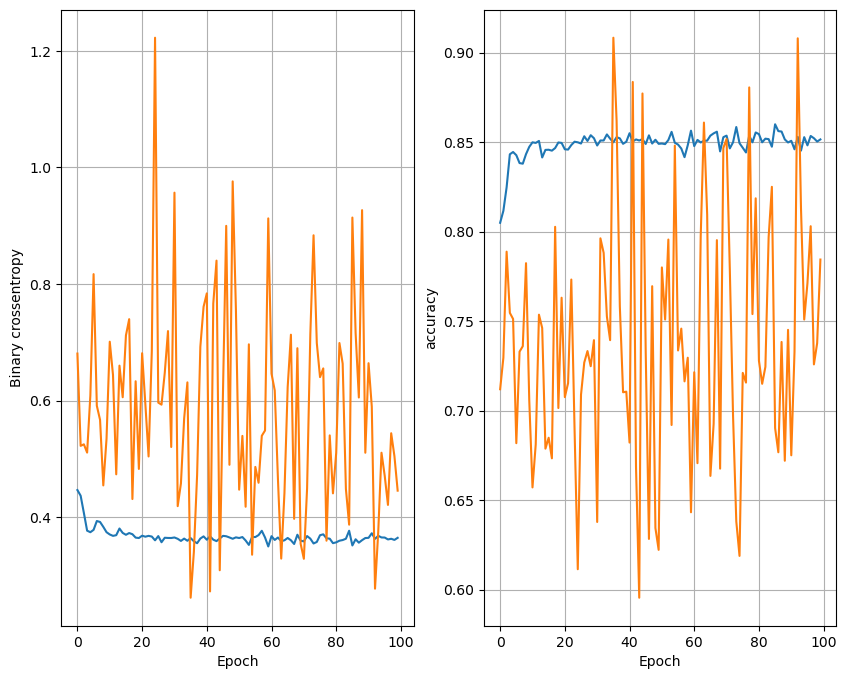

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8444 - loss: 0.3819
32 nodes, dropout 0, lr 0.1, batch_size 64, epochs 100


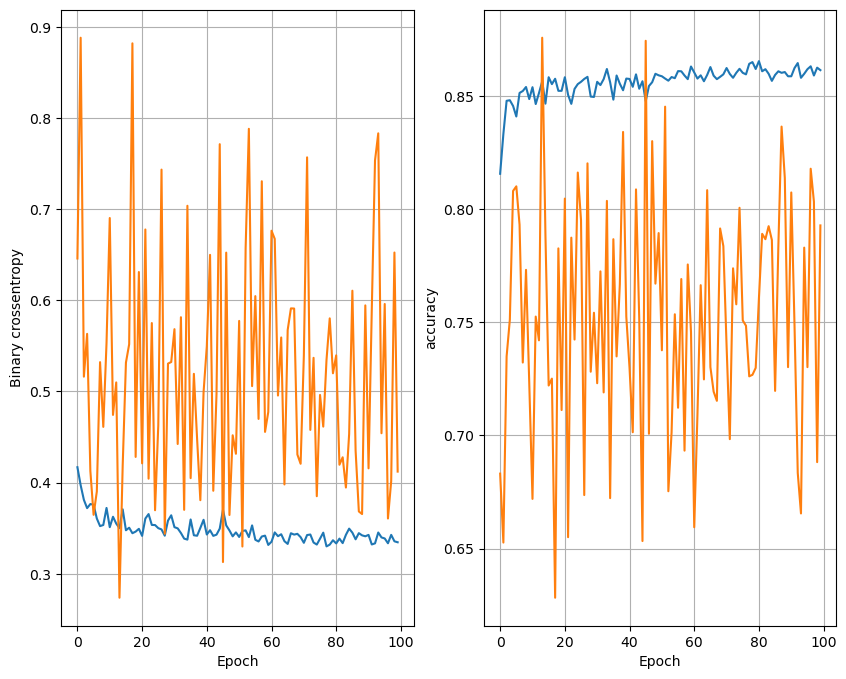

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8520 - loss: 0.3601
32 nodes, dropout 0, lr 0.1, batch_size 128, epochs 100


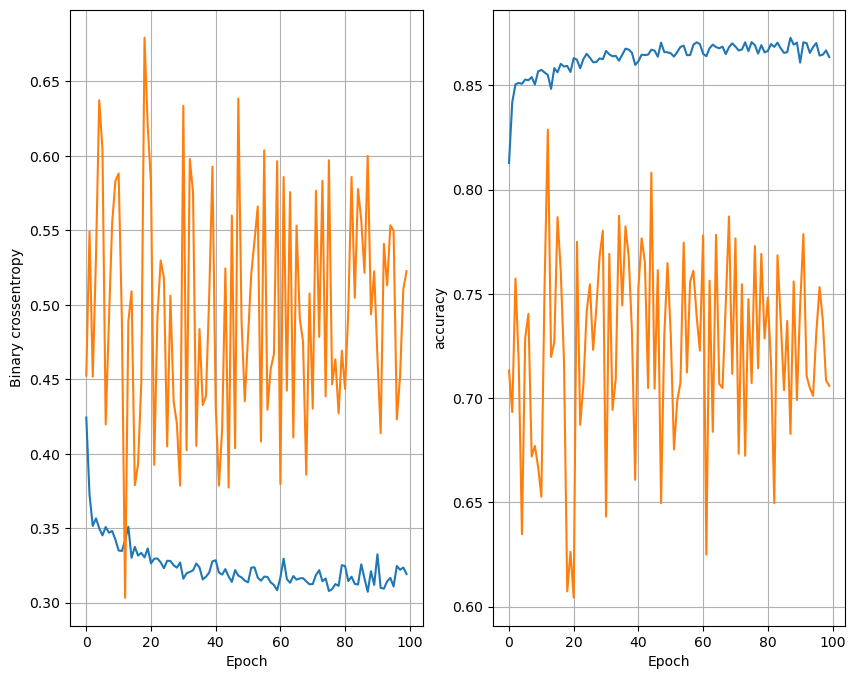

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8693 - loss: 0.3419
32 nodes, dropout 0, lr 0.005, batch_size 32, epochs 100


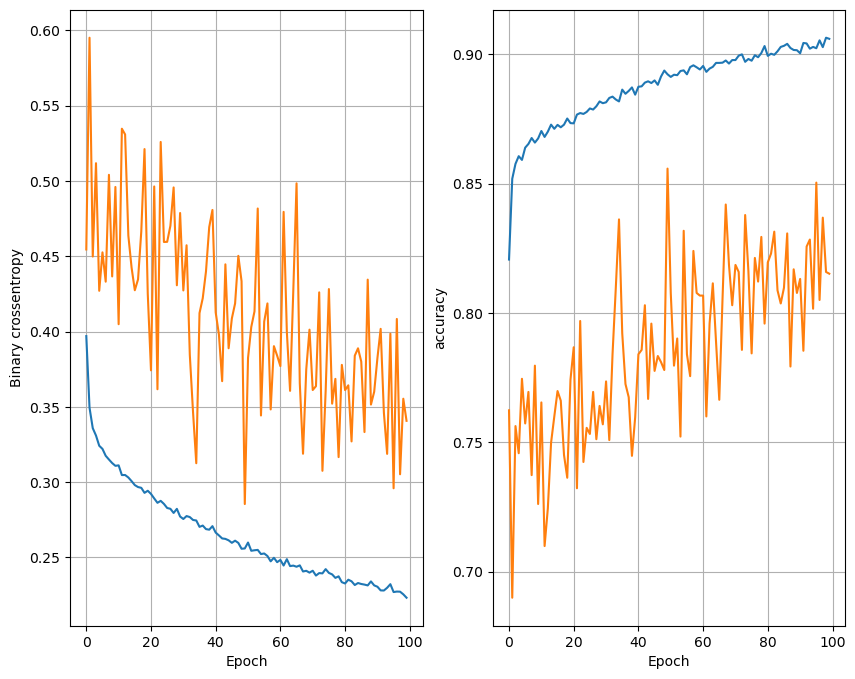

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8638 - loss: 0.3790
32 nodes, dropout 0, lr 0.005, batch_size 64, epochs 100


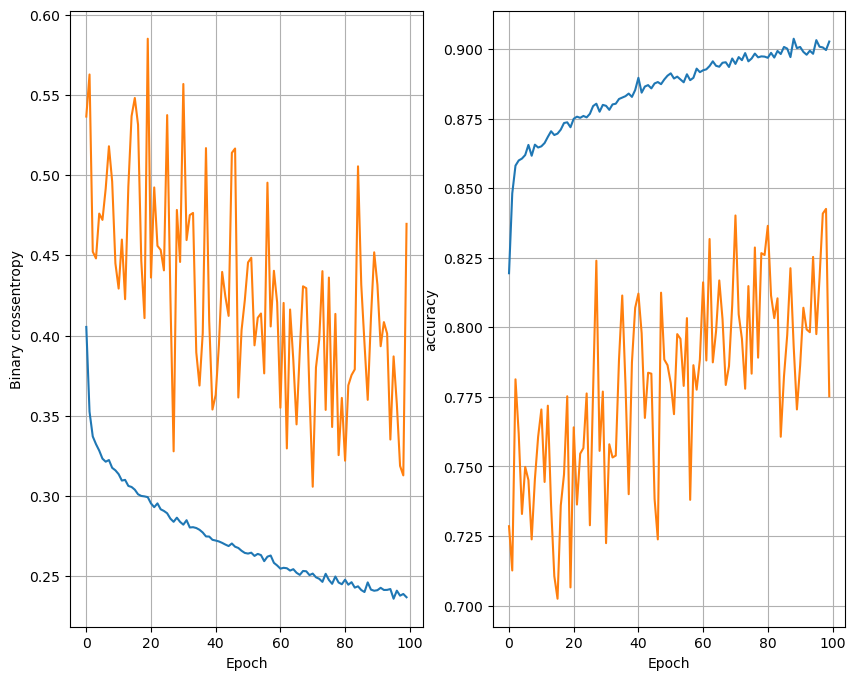

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8743 - loss: 0.3611
32 nodes, dropout 0, lr 0.005, batch_size 128, epochs 100


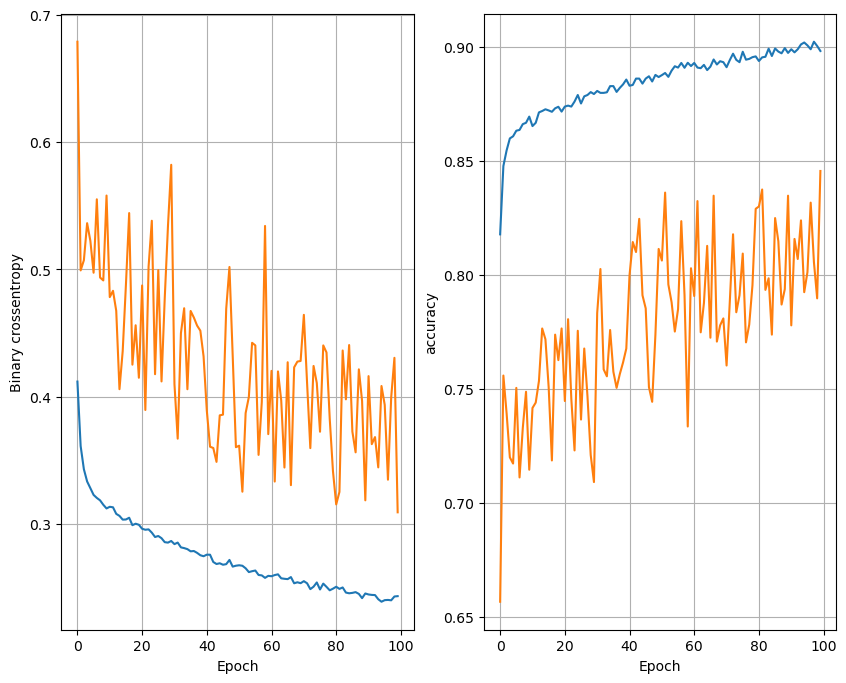

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8625 - loss: 0.3689
32 nodes, dropout 0, lr 0.001, batch_size 32, epochs 100


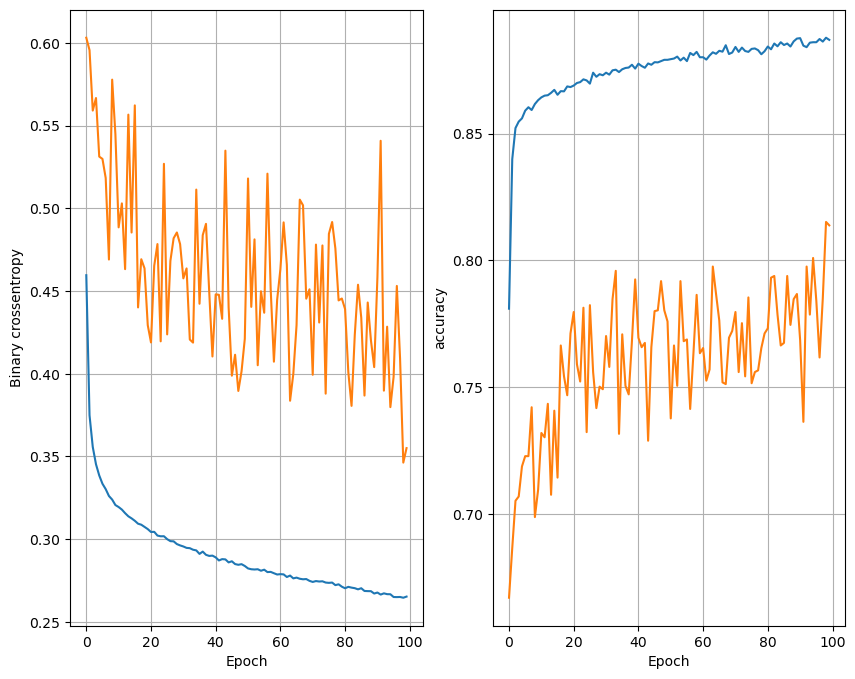

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8667 - loss: 0.3303
32 nodes, dropout 0, lr 0.001, batch_size 64, epochs 100


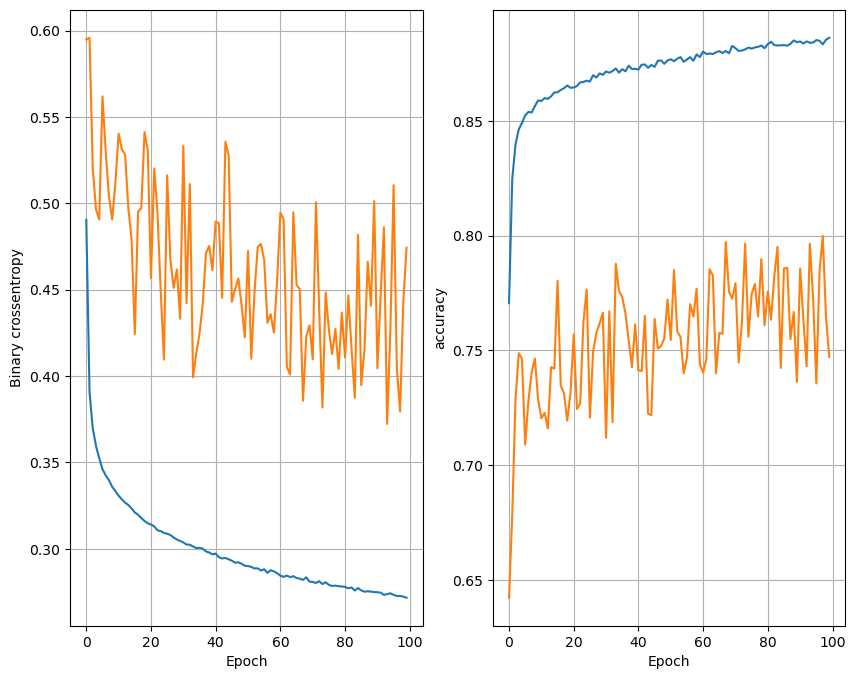

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8778 - loss: 0.3130
32 nodes, dropout 0, lr 0.001, batch_size 128, epochs 100


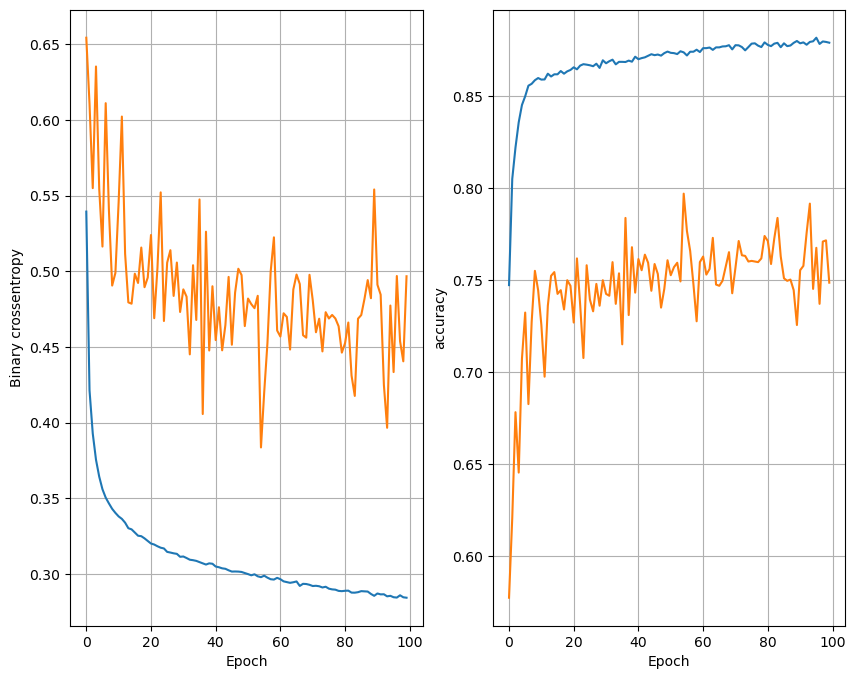

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8759 - loss: 0.3097
32 nodes, dropout 0.2, lr 0.1, batch_size 32, epochs 100


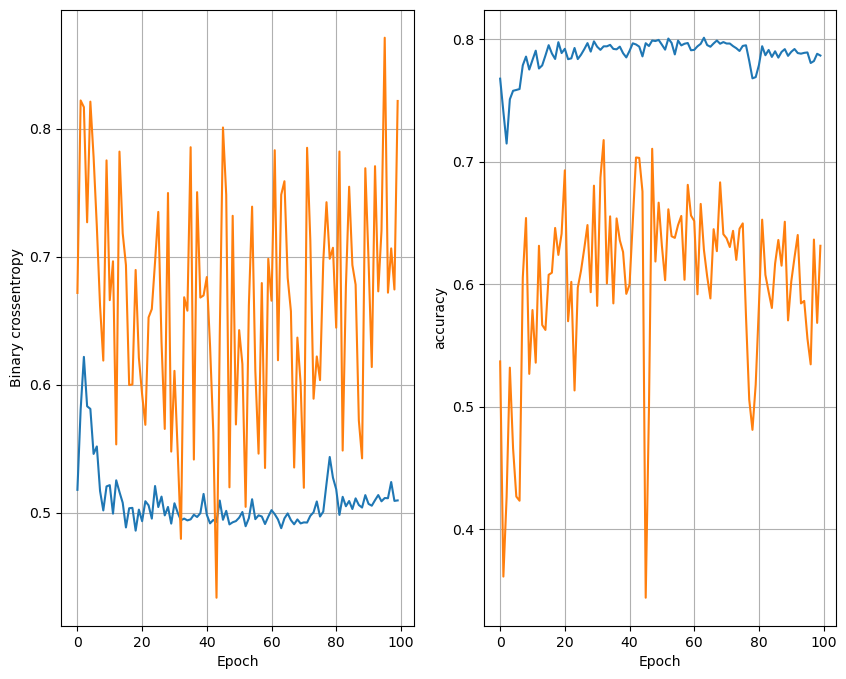

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8457 - loss: 0.4630
32 nodes, dropout 0.2, lr 0.1, batch_size 64, epochs 100


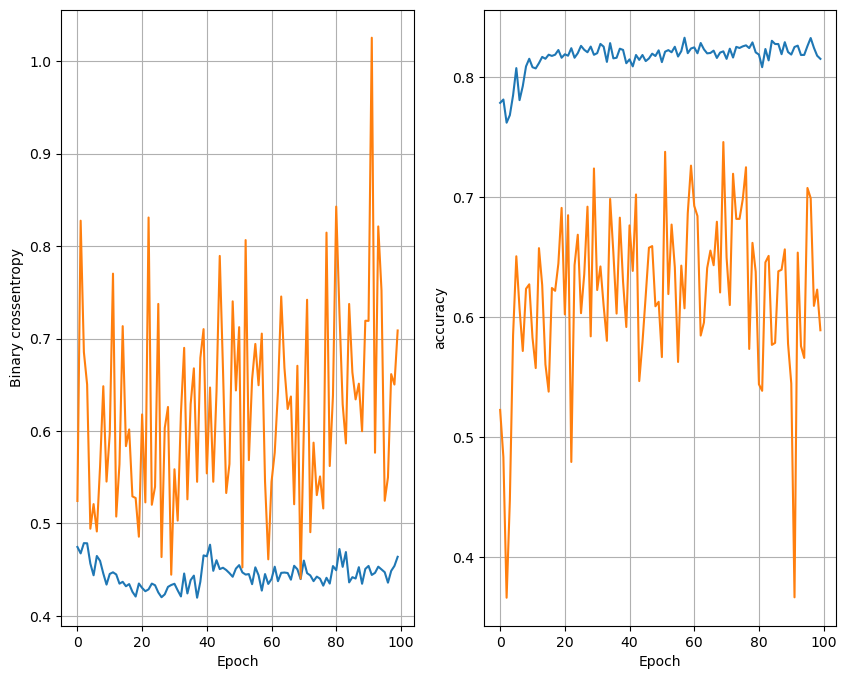

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8475 - loss: 0.4083
32 nodes, dropout 0.2, lr 0.1, batch_size 128, epochs 100


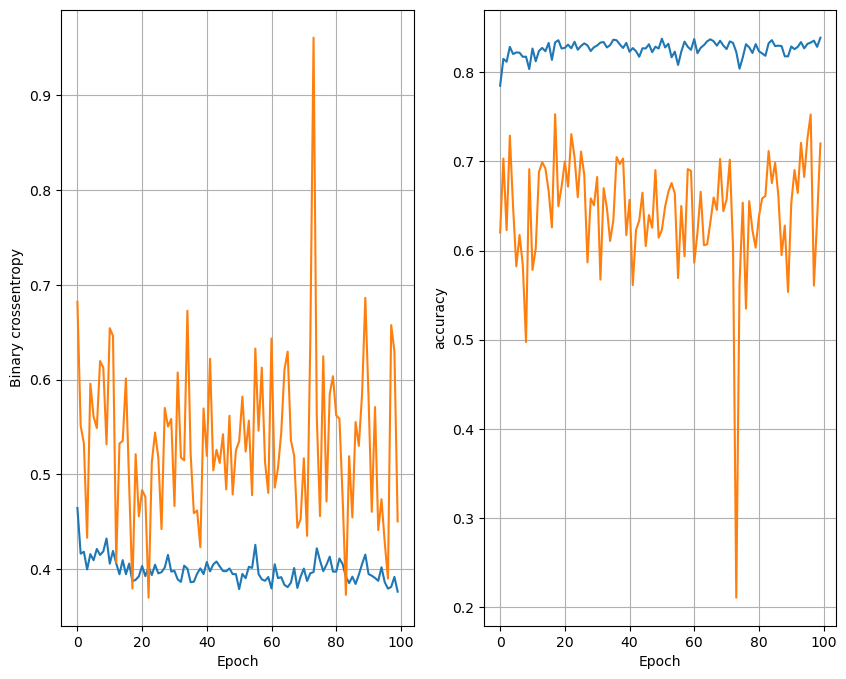

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8686 - loss: 0.3390
32 nodes, dropout 0.2, lr 0.005, batch_size 32, epochs 100


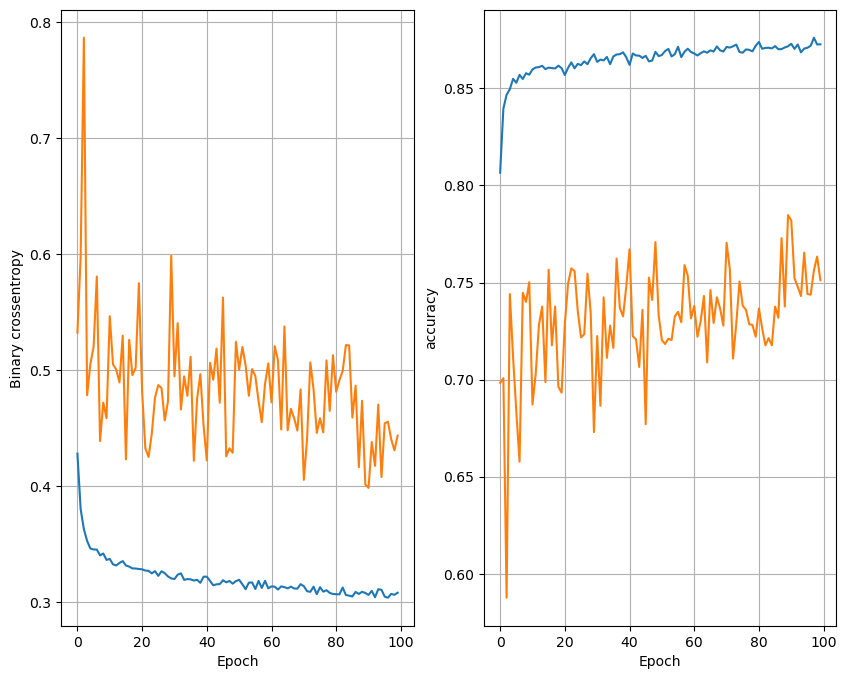

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8762 - loss: 0.3095
32 nodes, dropout 0.2, lr 0.005, batch_size 64, epochs 100


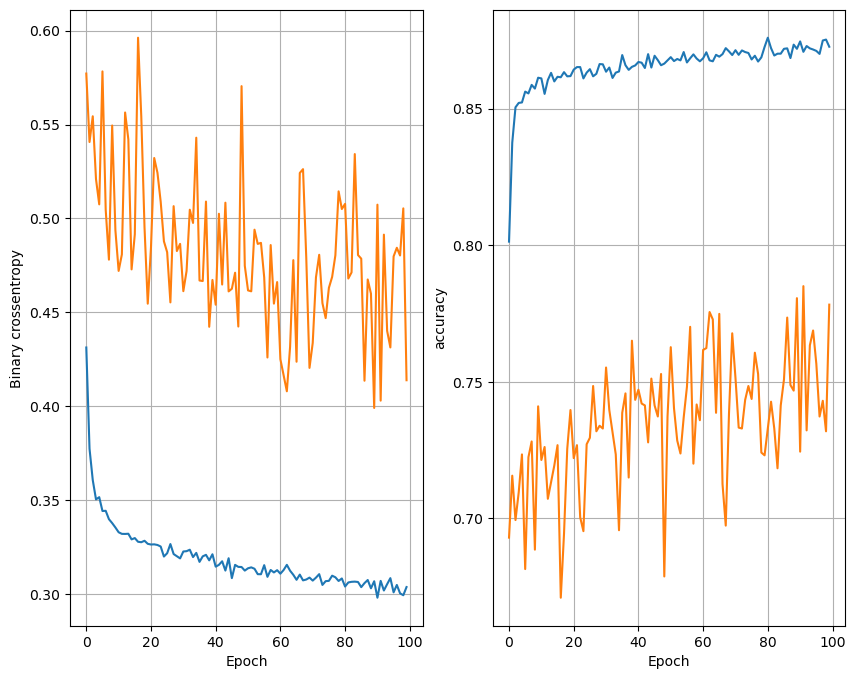

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8704 - loss: 0.3160
32 nodes, dropout 0.2, lr 0.005, batch_size 128, epochs 100


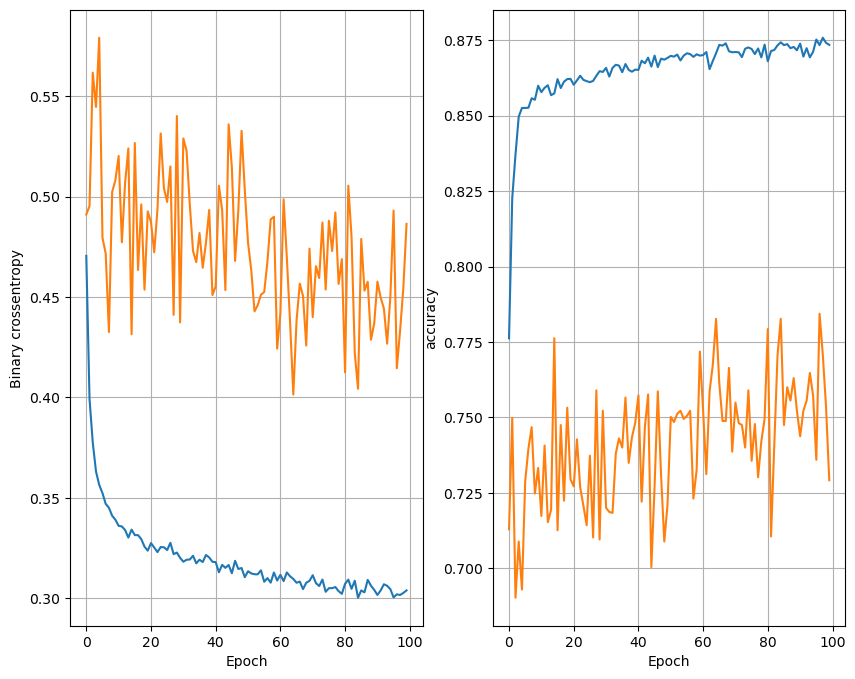

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8788 - loss: 0.2975
32 nodes, dropout 0.2, lr 0.001, batch_size 32, epochs 100


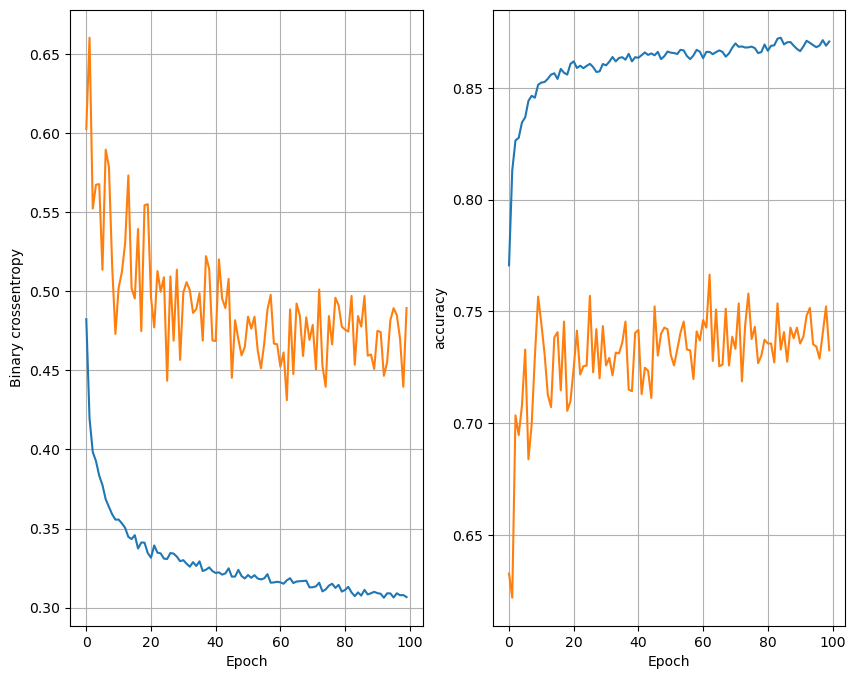

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8791 - loss: 0.3016
32 nodes, dropout 0.2, lr 0.001, batch_size 64, epochs 100


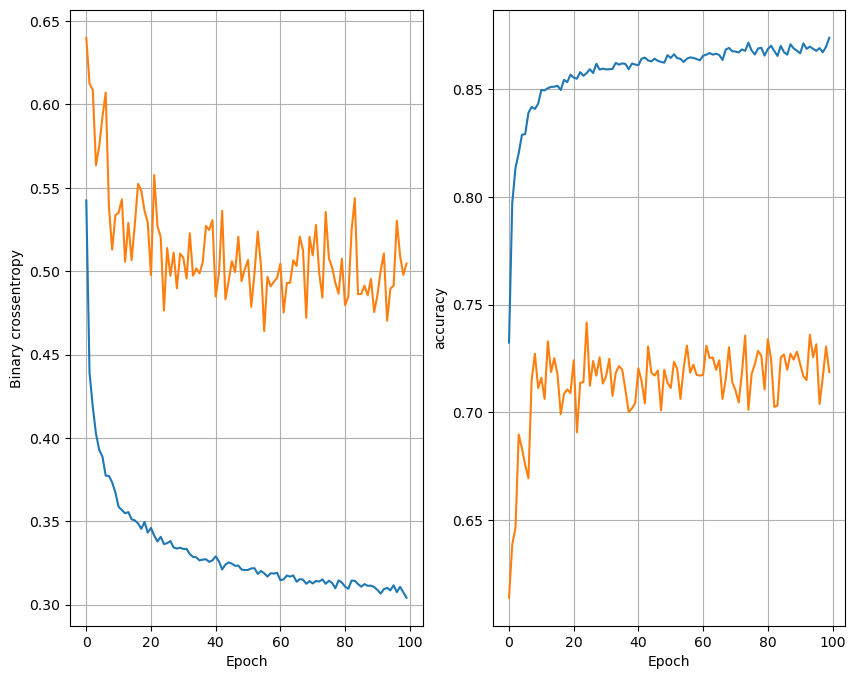

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8738 - loss: 0.3007
32 nodes, dropout 0.2, lr 0.001, batch_size 128, epochs 100


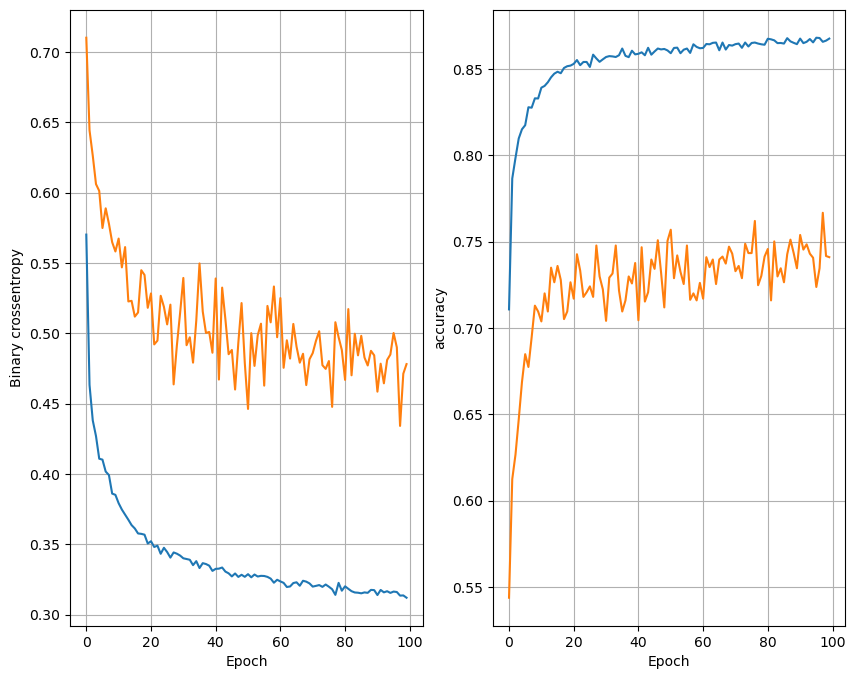

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8738 - loss: 0.3018
64 nodes, dropout 0, lr 0.1, batch_size 32, epochs 100


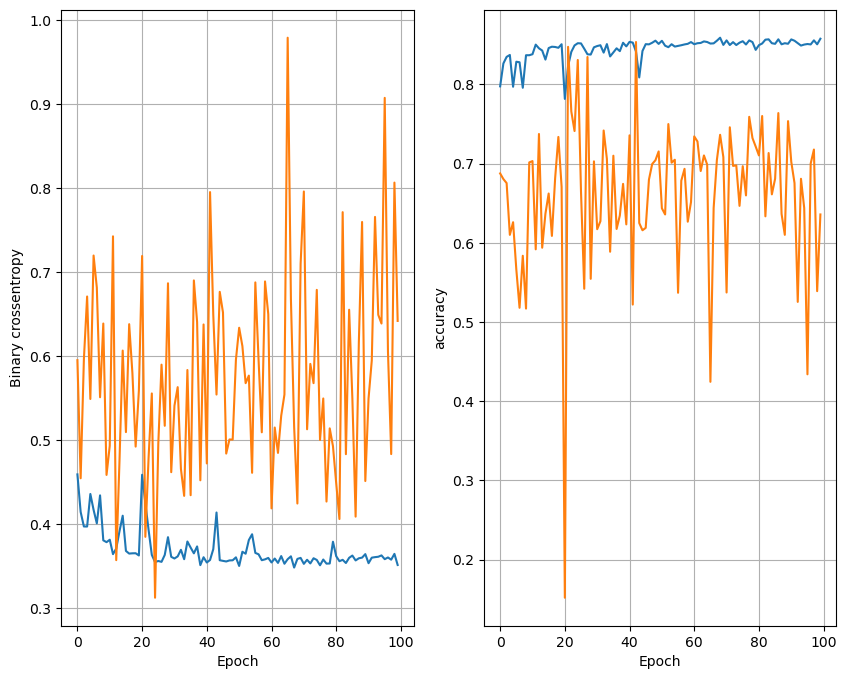

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8580 - loss: 0.3558
64 nodes, dropout 0, lr 0.1, batch_size 64, epochs 100


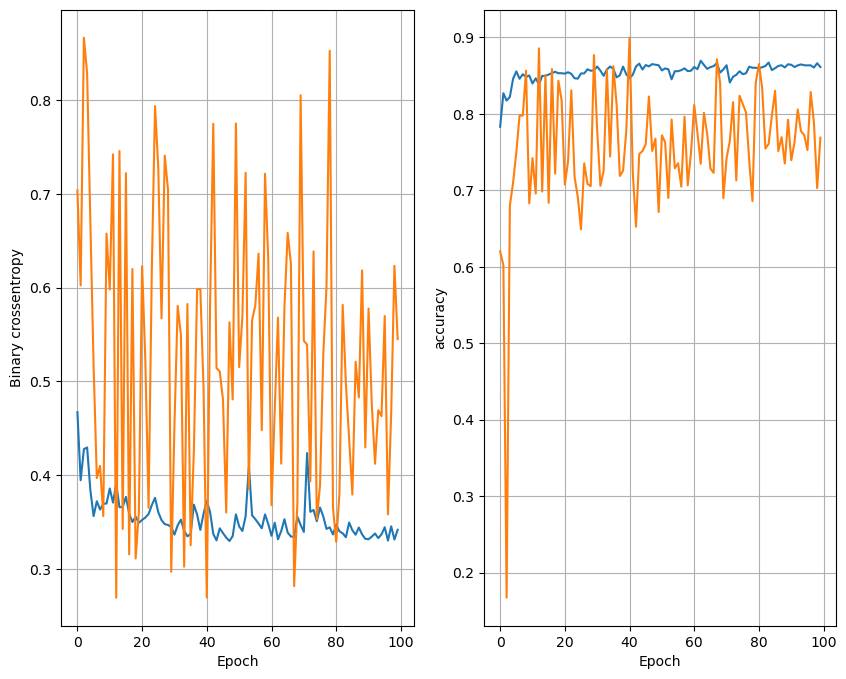

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8612 - loss: 0.3339
64 nodes, dropout 0, lr 0.1, batch_size 128, epochs 100


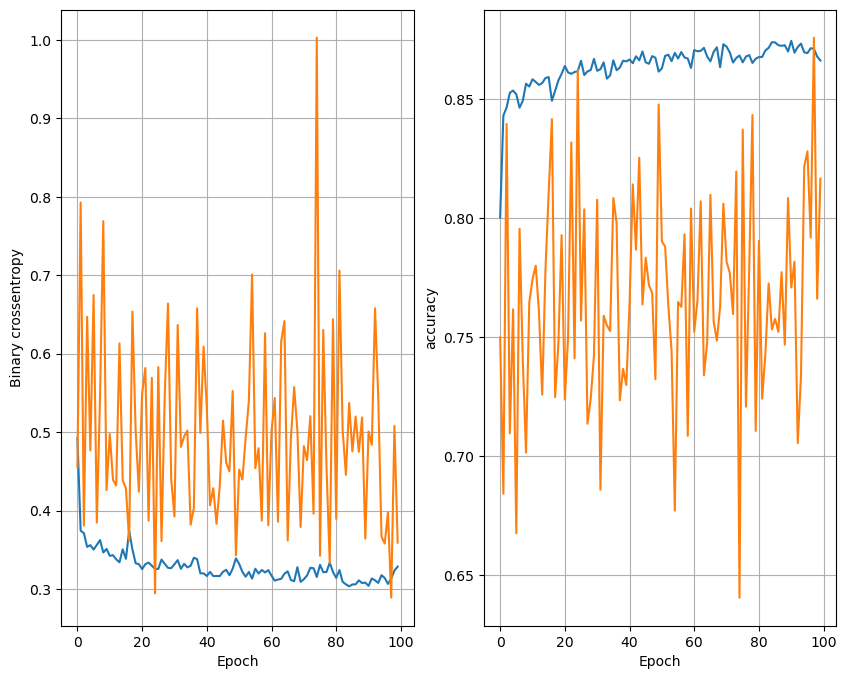

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8454 - loss: 0.3871
64 nodes, dropout 0, lr 0.005, batch_size 32, epochs 100


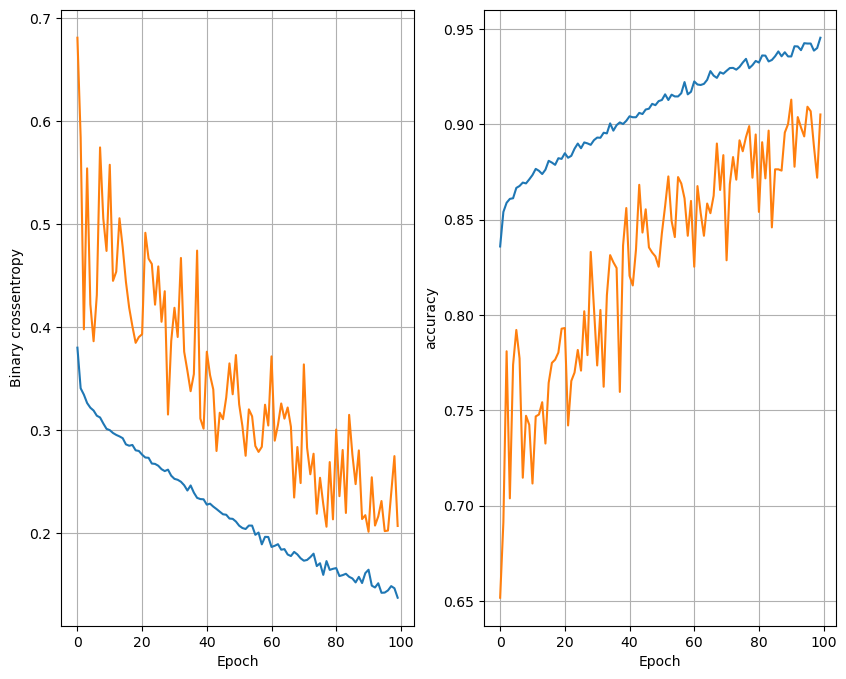

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8567 - loss: 0.6220
64 nodes, dropout 0, lr 0.005, batch_size 64, epochs 100


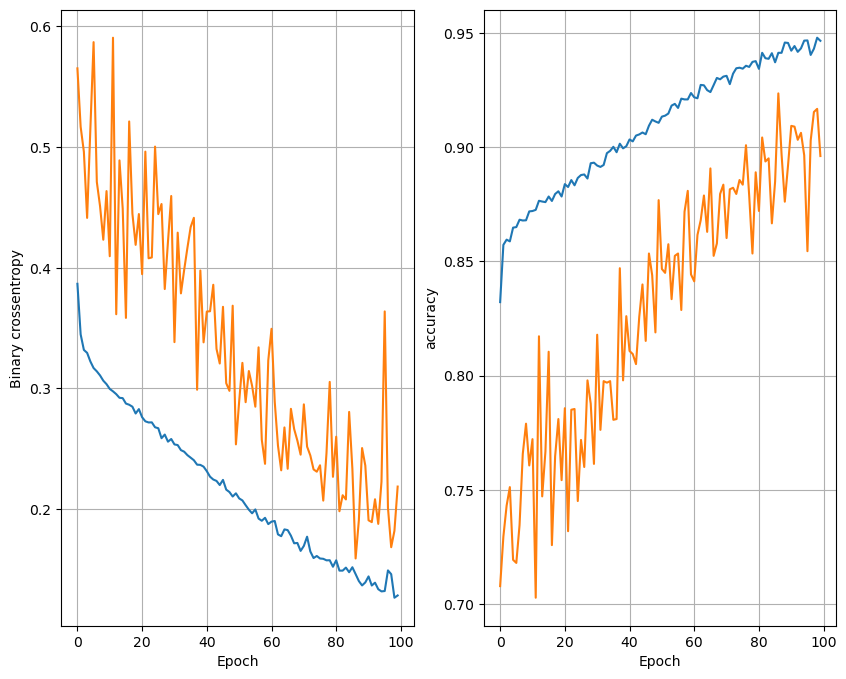

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8507 - loss: 0.6240
64 nodes, dropout 0, lr 0.005, batch_size 128, epochs 100


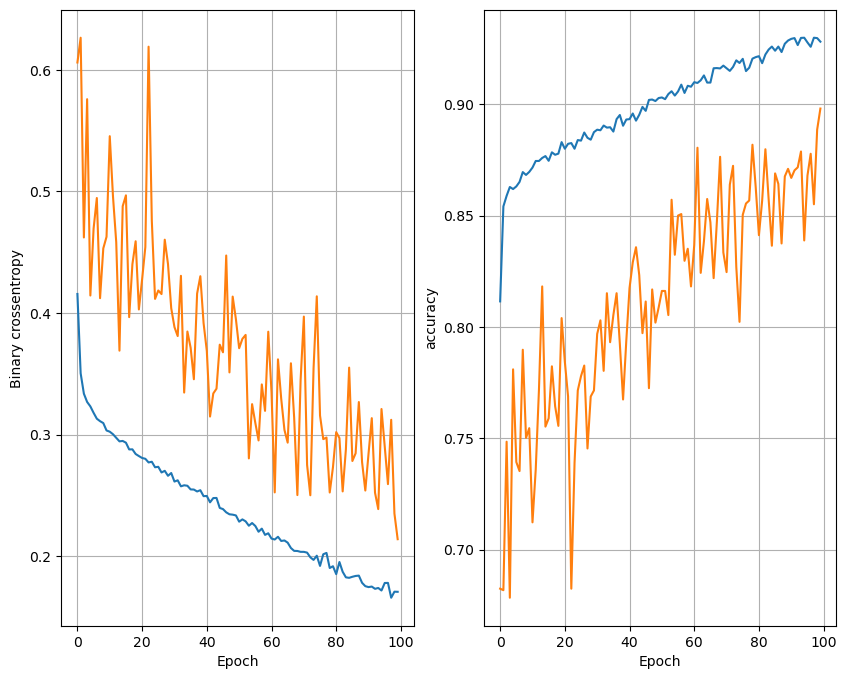

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8499 - loss: 0.4996
64 nodes, dropout 0, lr 0.001, batch_size 32, epochs 100


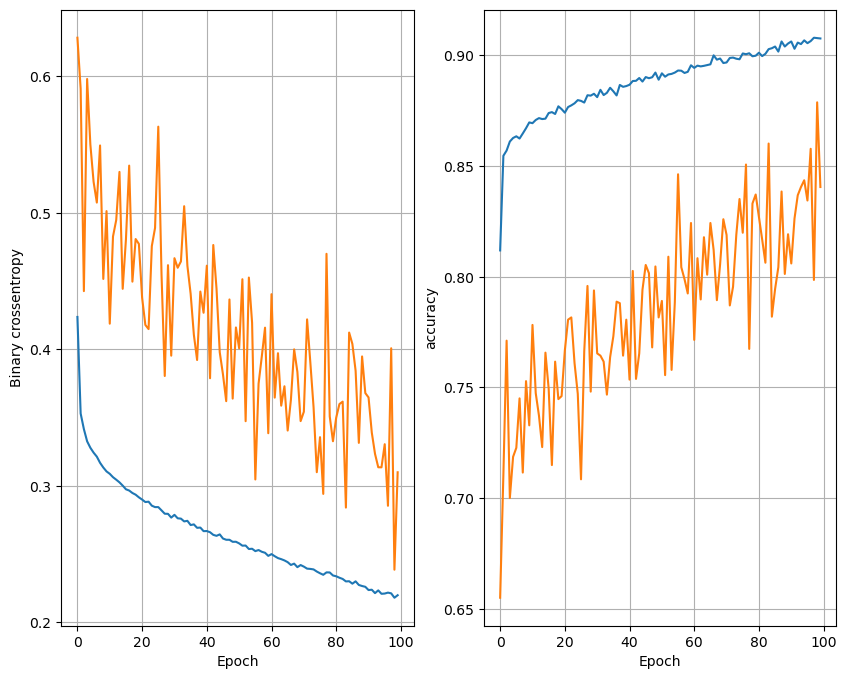

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8725 - loss: 0.3621
64 nodes, dropout 0, lr 0.001, batch_size 64, epochs 100


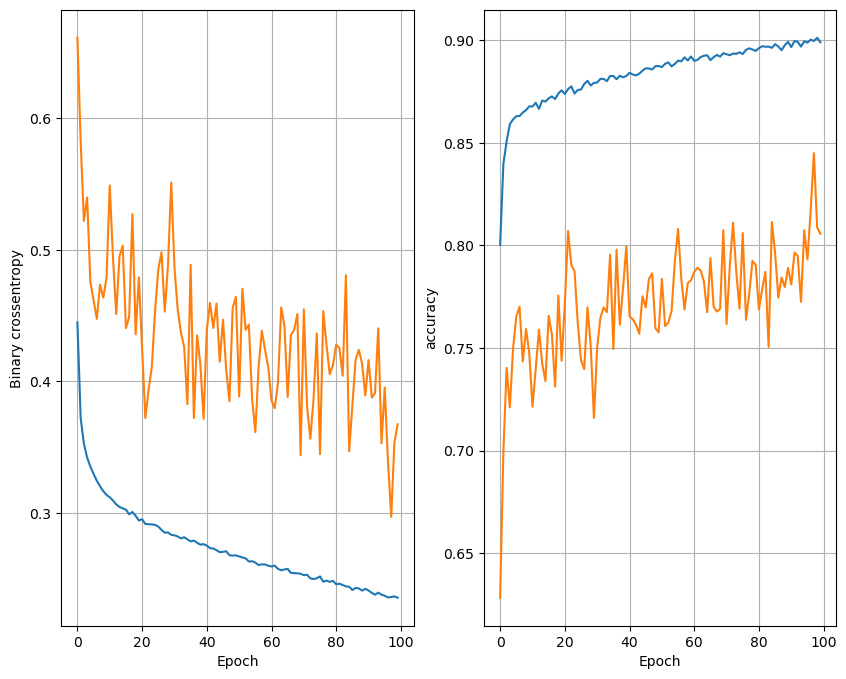

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8675 - loss: 0.3517
64 nodes, dropout 0, lr 0.001, batch_size 128, epochs 100


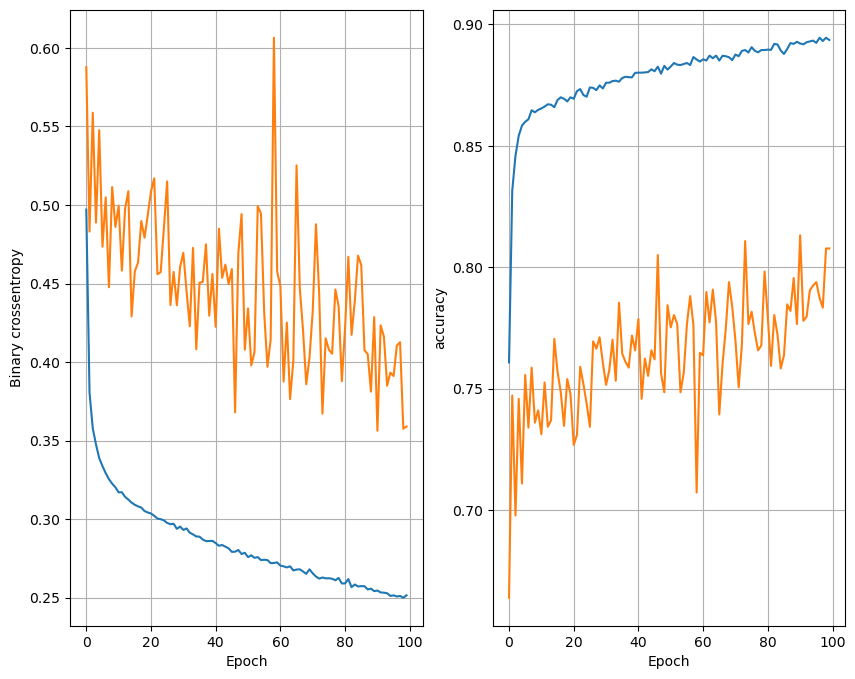

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8722 - loss: 0.3357
64 nodes, dropout 0.2, lr 0.1, batch_size 32, epochs 100


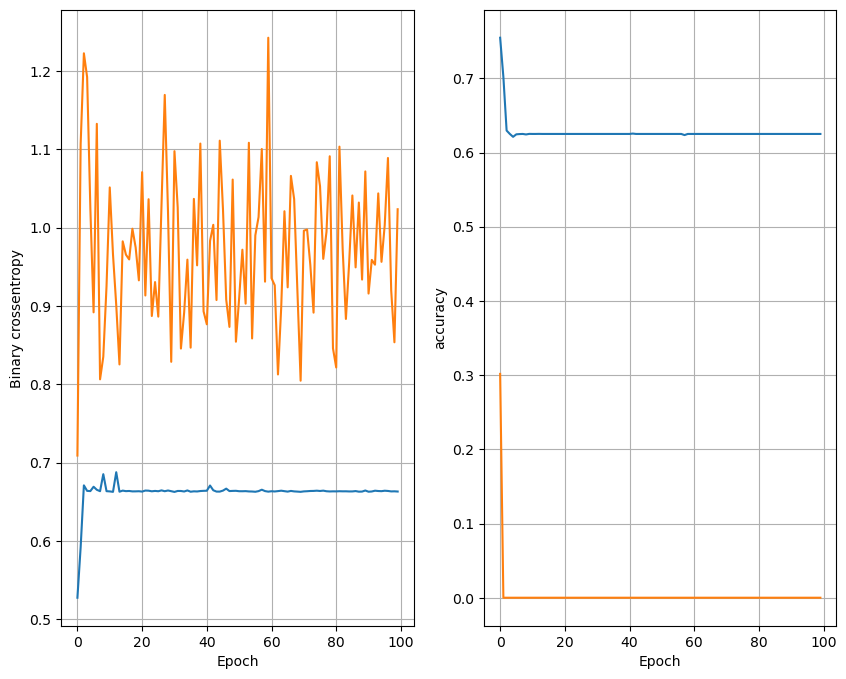

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6588 - loss: 0.6426
64 nodes, dropout 0.2, lr 0.1, batch_size 64, epochs 100


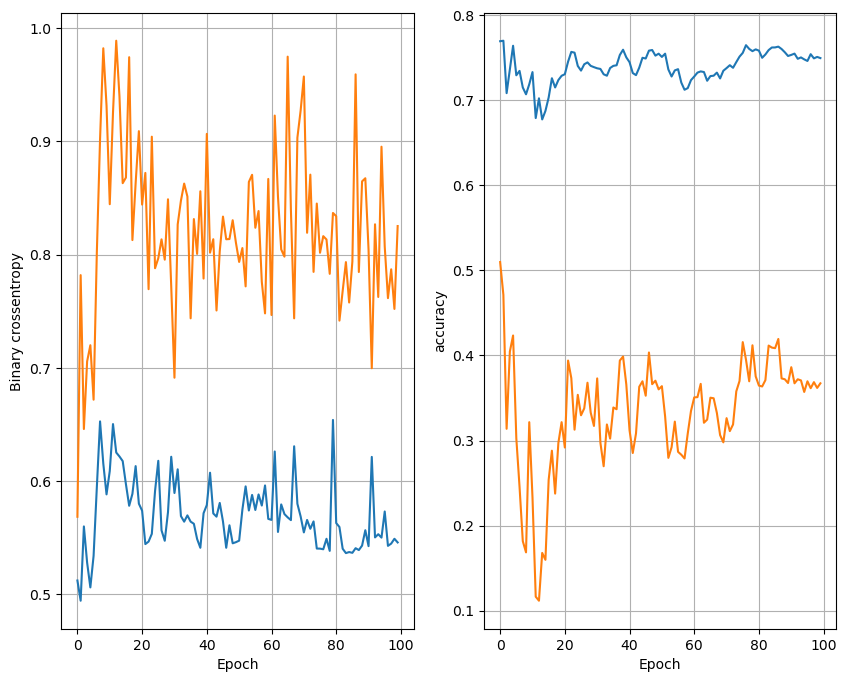

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7750 - loss: 0.5265
64 nodes, dropout 0.2, lr 0.1, batch_size 128, epochs 100


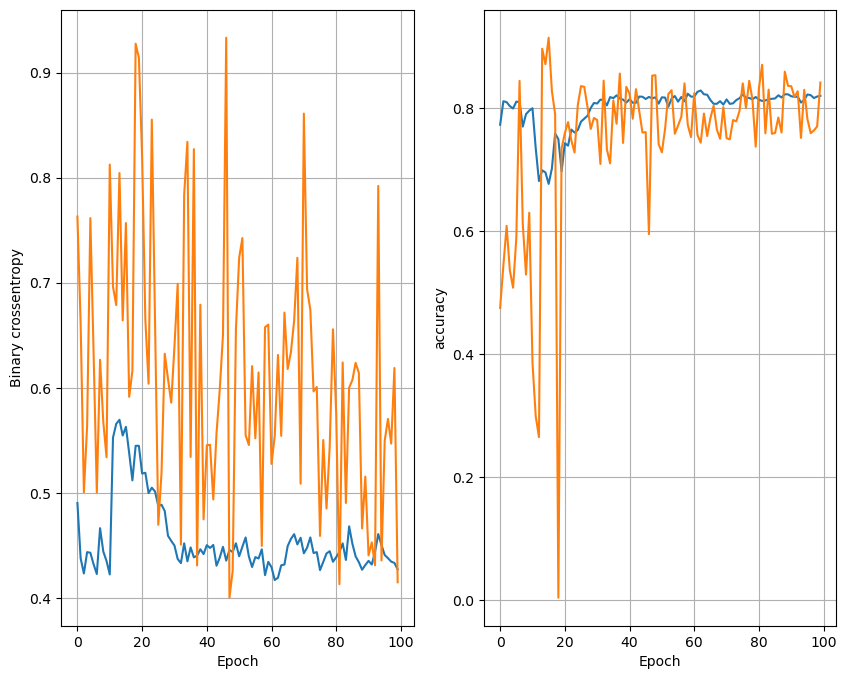

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8170 - loss: 0.4140
64 nodes, dropout 0.2, lr 0.005, batch_size 32, epochs 100


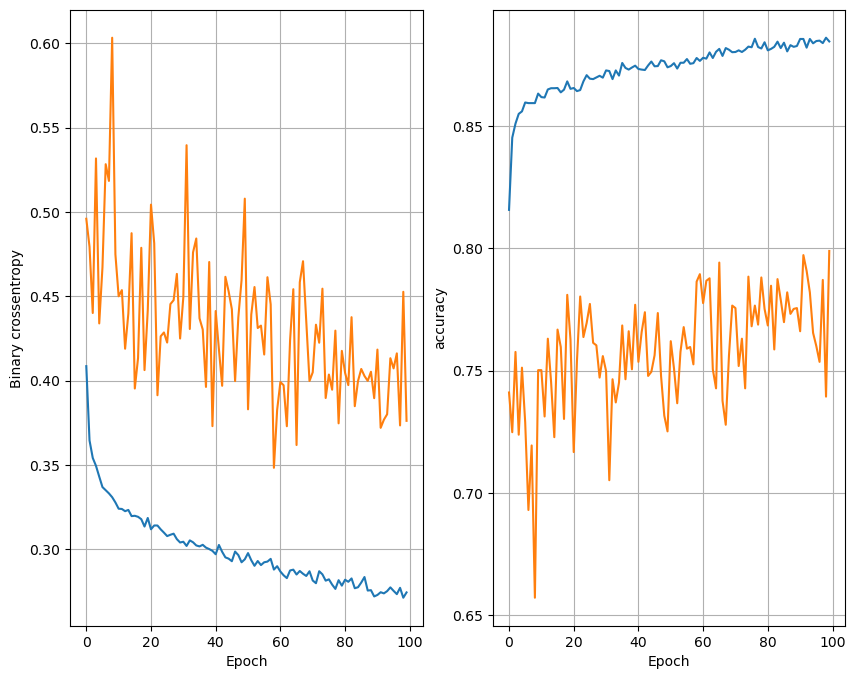

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8701 - loss: 0.3422
64 nodes, dropout 0.2, lr 0.005, batch_size 64, epochs 100


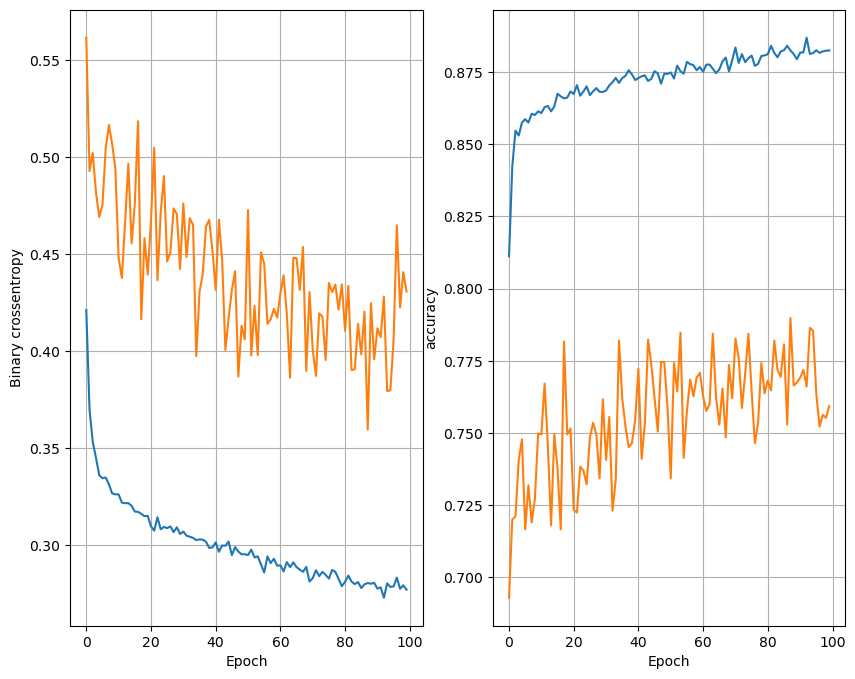

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8817 - loss: 0.3128
64 nodes, dropout 0.2, lr 0.005, batch_size 128, epochs 100


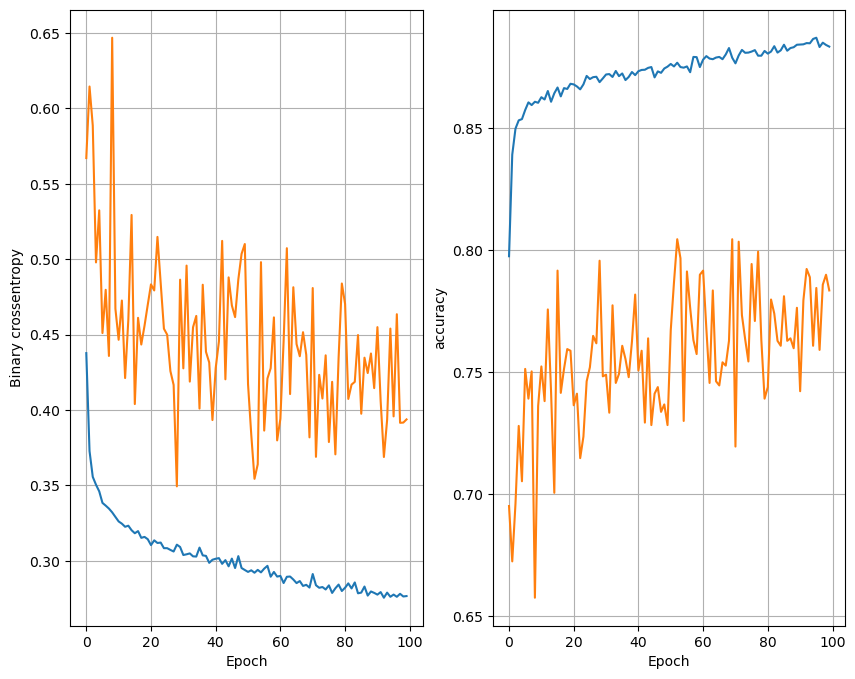

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8796 - loss: 0.3043
64 nodes, dropout 0.2, lr 0.001, batch_size 32, epochs 100


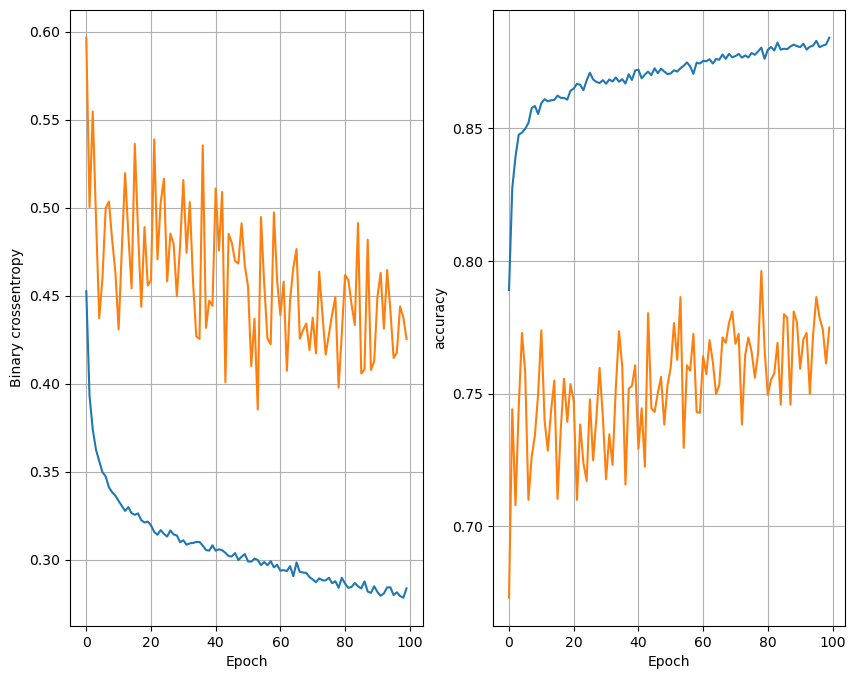

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8807 - loss: 0.3010
64 nodes, dropout 0.2, lr 0.001, batch_size 64, epochs 100


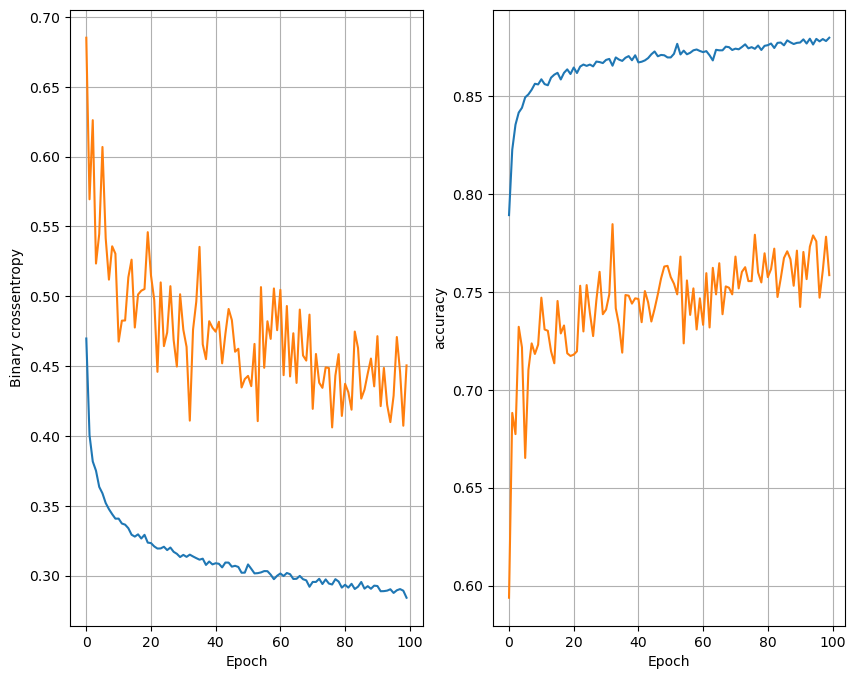

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8807 - loss: 0.2997
64 nodes, dropout 0.2, lr 0.001, batch_size 128, epochs 100


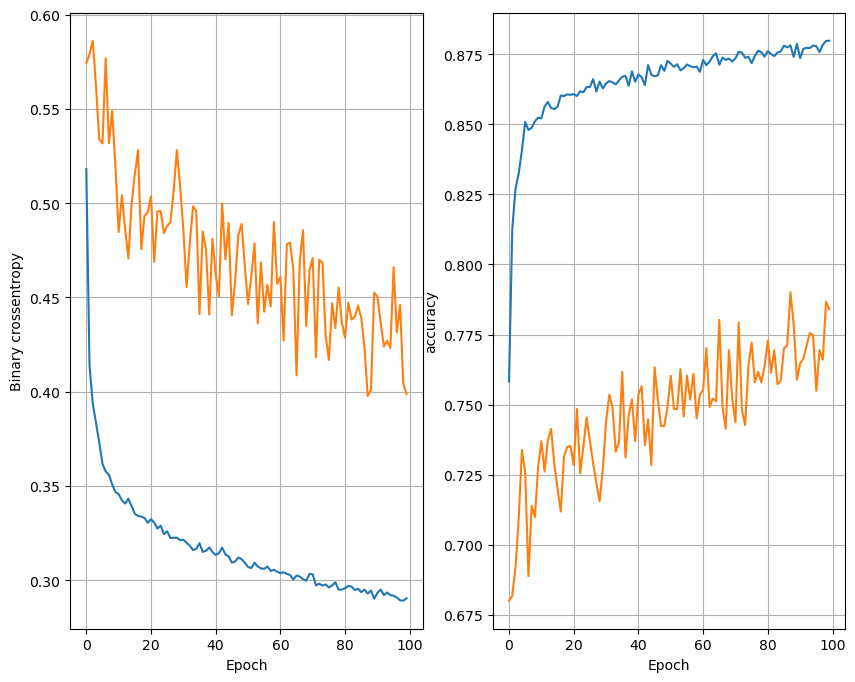

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8736 - loss: 0.3049


In [35]:
epochs = 100
least_loss_model = None
least_val_loss = float('inf')
for num_nodes in [16, 32, 64]:
    for dropout_prob in [0, 0.2]:
        for lr in [0.1, 0.005, 0.001]:
            for batch_size in [32, 64, 128]:
                  print(f"{num_nodes} nodes, dropout {dropout_prob}, lr {lr}, batch_size {batch_size}, epochs {epochs}")
                  model, history = train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
                  plot_history(history)
                  val_loss = model.evaluate(X_valid, y_valid)[0]
                  if val_loss < least_val_loss:
                       least_val_loss = val_loss
                       least_loss_model = model

In [38]:
y_pred = least_loss_model.predict(X_test)

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [39]:
y_pred = (y_pred > 0.5).astype(int)

In [41]:
y_pred = y_pred.reshape(-1,)

In [42]:
y_pred

array([1, 1, 1, ..., 0, 1, 1], shape=(3804,))

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.90      0.74      0.81      1362
         1.0       0.87      0.96      0.91      2442

    accuracy                           0.88      3804
   macro avg       0.89      0.85      0.86      3804
weighted avg       0.88      0.88      0.87      3804

